<a href="https://www.kaggle.com/code/sm39sinp/obesity-data-classification?scriptVersionId=249761674" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/obesity-prediction/Obesity prediction.csv


In [2]:
df = pd.read_csv("/kaggle/input/obesity-prediction/Obesity prediction.csv")
df.head(5)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df["Gender"] = (df["Gender"] == "Male").astype(int)

In [4]:
df["family_history"] = (df["family_history"] == "yes").astype(int)

In [5]:
df["SMOKE"] = (df["SMOKE"] == "yes").astype(int)

In [6]:
df["SCC"] = (df["SCC"] == "yes").astype(int)

In [7]:
df["FAVC"] = (df["FAVC"] == "yes").astype(int)

In [8]:
CALC_numaric = {'CALC': {'no':0, 'Sometimes':1, 'Frequently':2, 'Always':3}}
df = df.replace(CALC_numaric)
CAEC_numaric = {'CAEC': {'no':0, 'Sometimes':1, 'Frequently':2 , 'Always':3}}
df = df.replace(CAEC_numaric)
MTRANS_numaric = {'MTRANS': {'Walking':0, 'Public_Transportation':1, 'Motorbike':1 , 'Bike':1 , 'Automobile':1}}
df = df.replace(MTRANS_numaric)
Obesity_numaric = {'Obesity': {'Insufficient_Weight':0,'Normal_Weight':1, 'Overweight_Level_I':2, 'Overweight_Level_II':3, 'Obesity_Type_I':4,'Obesity_Type_II':5,'Obesity_Type_III':6}}
df = df.replace(Obesity_numaric)
#creating BMI and scaling 
df['BMI'] = (df.Weight/(df.Height*df.Height)) 
df['BMI'] = df.BMI/df['BMI'].mean()
# scaling age 
df['Age'] = df.Age/df['Age'].mean()
#dropping Height and weight
df = df.drop(['Height', 'Weight'], axis=1)
#moving Obesity to the Right
BMI_col = df.pop('BMI')
df.insert(2, 'BMI', BMI_col)


<ipython-input-8-27cc7bde9360>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(CALC_numaric)
<ipython-input-8-27cc7bde9360>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(CAEC_numaric)
<ipython-input-8-27cc7bde9360>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df =

In [9]:
df.head(100)

,Gender,Age,BMI,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,0,0.863750,0.821091,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,1,1
1,0,0.863750,0.816098,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,1,1
2,1,0.946012,0.800179,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,1,1
3,1,1.110535,0.904098,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,0,2
4,1,0.904881,0.954284,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,1.069404,0.815533,1,0,3.0,1.0,2,0,2.0,0,2.0,0.0,2,1,1
96,0,0.946012,0.733122,1,0,2.0,3.0,1,0,2.0,0,3.0,0.0,1,1,1
97,0,0.863750,0.612073,0,0,3.0,1.0,2,0,1.0,0,0.0,0.0,1,1,0
98,0,0.863750,0.612073,0,0,3.0,1.0,2,0,1.0,0,0.0,0.0,1,1,0


In [10]:
df_ml = df

In [11]:
print(len(df_ml[df_ml["Obesity"]==0]))
print(len(df_ml[df_ml["Obesity"]==1]))
print(len(df_ml[df_ml["Obesity"]==2]))
print(len(df_ml[df_ml["Obesity"]==3]))

272
287
290
290


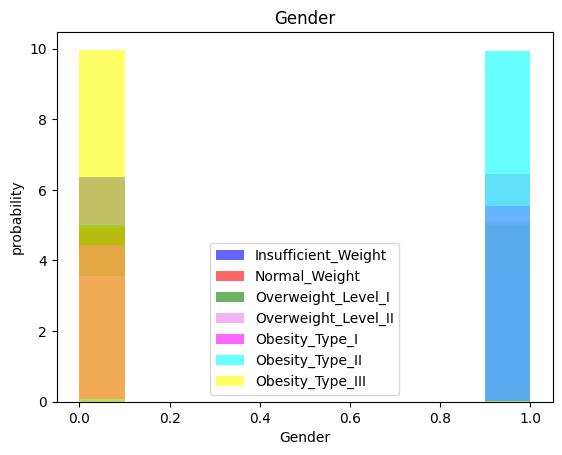

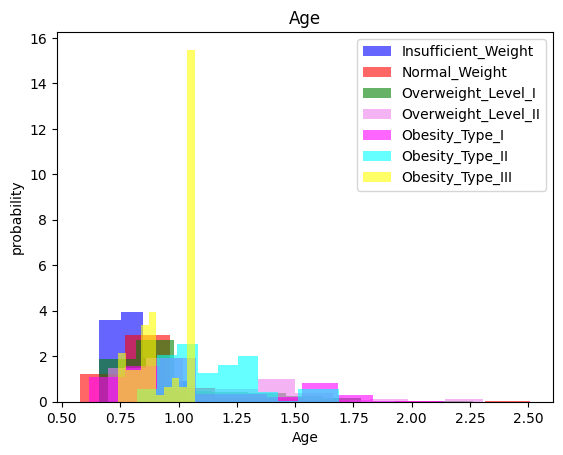

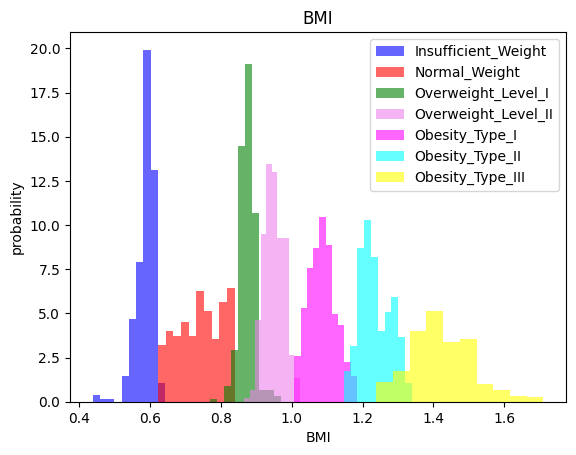

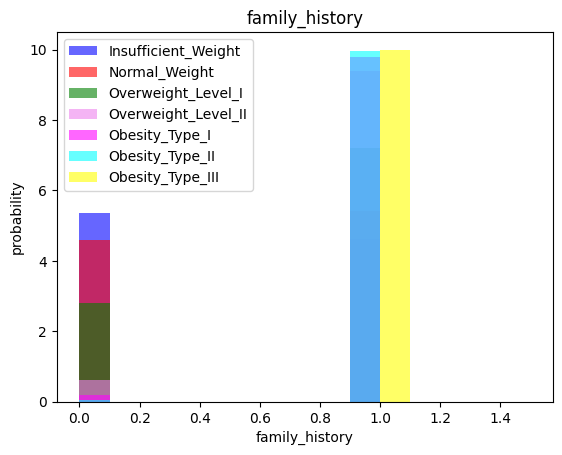

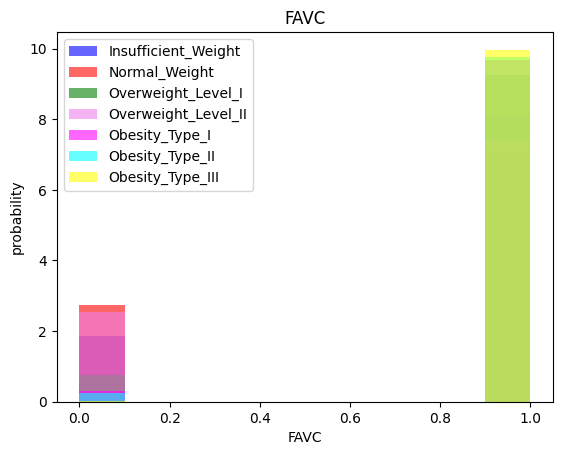

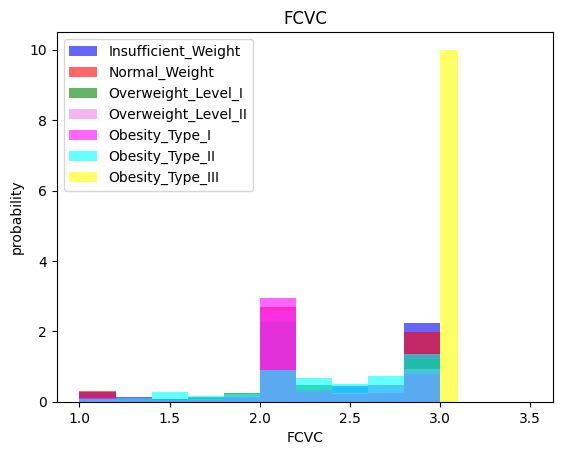

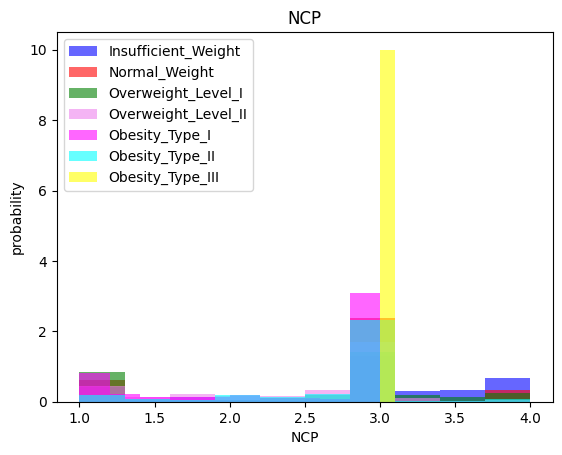

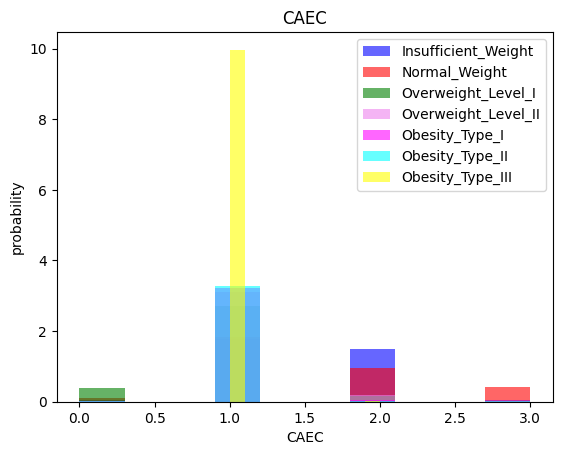

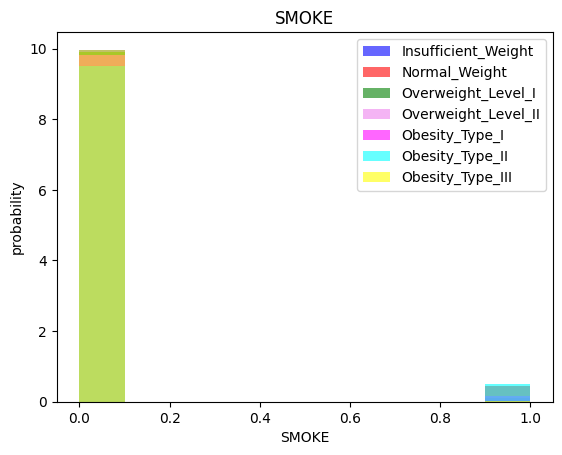

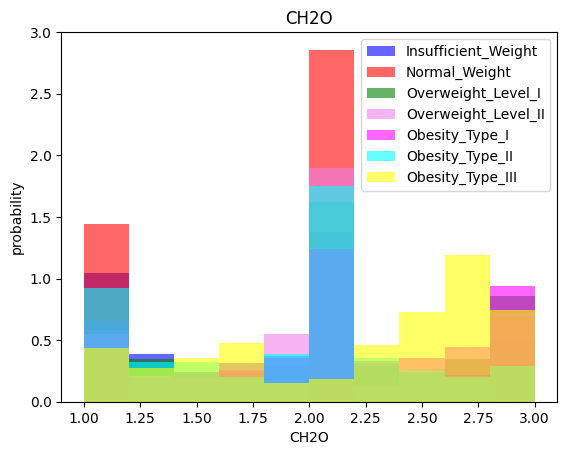

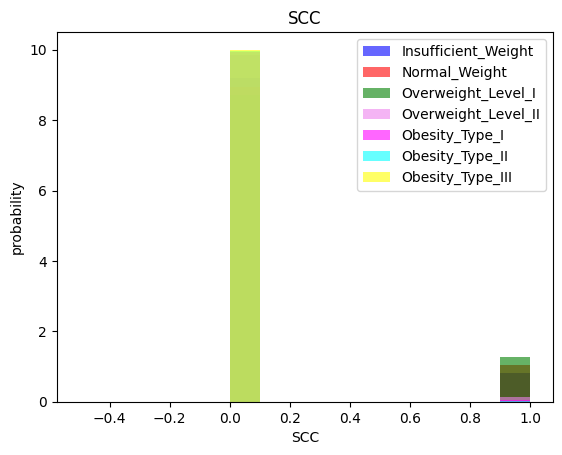

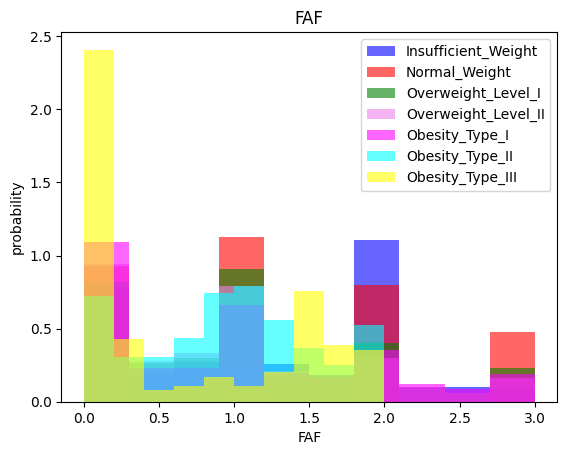

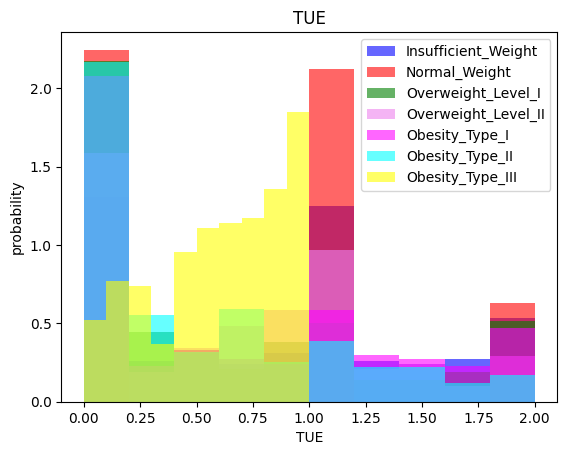

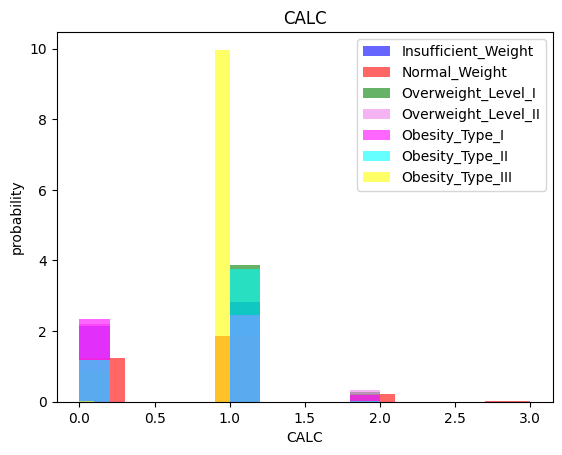

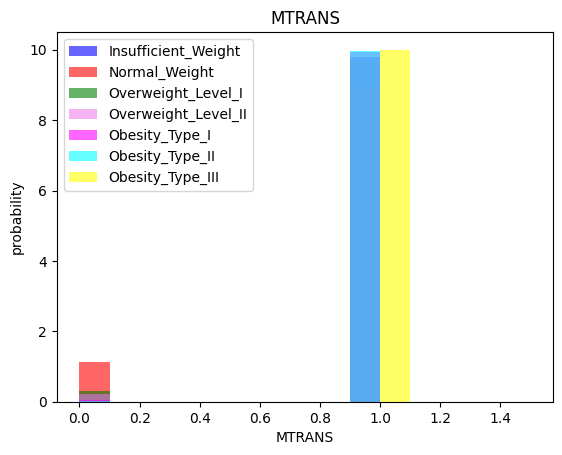

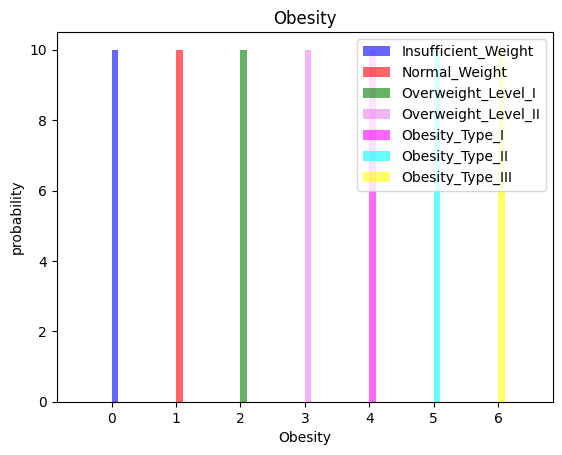

In [12]:
for label in df[:-1]:
  plt.hist(df[df["Obesity"]==0][label],color = 'blue', label ='Insufficient_Weight', alpha = 0.6, density =True)
  plt.hist(df[df["Obesity"]==1][label],color = 'red', label ='Normal_Weight', alpha = 0.6, density =True)
  plt.hist(df[df["Obesity"]==2][label],color = 'green', label ='Overweight_Level_I', alpha = 0.6, density =True)
  plt.hist(df[df["Obesity"]==3][label],color = 'violet', label ='Overweight_Level_II', alpha = 0.6, density =True)
  plt.hist(df[df["Obesity"]==4][label],color = 'magenta', label ='Obesity_Type_I', alpha = 0.6, density =True)
  plt.hist(df[df["Obesity"]==5][label],color = 'cyan', label ='Obesity_Type_II', alpha = 0.6, density =True)
  plt.hist(df[df["Obesity"]==6][label],color = 'yellow', label ='Obesity_Type_III', alpha = 0.6, density =True) 
  plt.title(label)
  plt.ylabel("probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

In [13]:
#spliting data
train, valid, test = np.split(df_ml.sample(frac = 1), [int(0.6*len(df_ml)), int(0.8*len(df_ml))])

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [14]:
print(len(train[train["Obesity"]==0]))
print(len(train[train["Obesity"]==1]))
print(len(train[train["Obesity"]==2]))
print(len(train[train["Obesity"]==3]))
print(len(train[train["Obesity"]==4]))
print(len(train[train["Obesity"]==5]))
print(len(train[train["Obesity"]==6]))

156
181
180
177
204
175
193


In [15]:
def scale_dataset(dataframe, oversample=False):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x)

  if oversample:
    ros = RandomOverSampler()
    x , y = ros.fit_resample(x,y)


  data = np.hstack((x,np.reshape(y,(-1,1))))
  return data , x, y

In [16]:
train, X_train, y_train = scale_dataset(train, oversample=False)
valid, X_valid, y_valid = scale_dataset(valid, oversample=False)
test, X_test, y_test = scale_dataset(test, oversample=False)

In [17]:
y_train

array([3, 3, 2, ..., 1, 2, 2])

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [19]:
knn_model = KNeighborsClassifier(n_neighbors=4)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4)

In [20]:
y_pred = knn_model.predict(X_test)

In [21]:
y_pred

array([1, 0, 1, 6, 4, 2, 6, 4, 1, 5, 6, 4, 1, 4, 1, 0, 0, 5, 0, 6, 5, 6,
       3, 1, 0, 6, 5, 0, 2, 0, 2, 0, 1, 2, 4, 0, 5, 2, 5, 2, 4, 4, 5, 3,
       5, 0, 2, 2, 6, 5, 4, 4, 6, 6, 6, 3, 6, 1, 0, 2, 5, 5, 5, 5, 6, 5,
       4, 6, 6, 6, 1, 3, 4, 4, 1, 5, 5, 4, 0, 1, 3, 4, 2, 6, 6, 5, 5, 0,
       1, 3, 2, 3, 3, 4, 3, 0, 4, 0, 4, 3, 0, 1, 0, 2, 3, 0, 2, 5, 2, 3,
       2, 3, 4, 6, 2, 6, 3, 1, 6, 4, 6, 0, 5, 6, 6, 3, 6, 4, 4, 5, 2, 3,
       2, 4, 1, 6, 4, 2, 6, 6, 2, 4, 6, 0, 5, 4, 0, 0, 1, 6, 5, 5, 4, 5,
       4, 5, 2, 1, 4, 5, 5, 6, 0, 4, 3, 4, 0, 4, 4, 1, 1, 2, 3, 6, 6, 5,
       6, 4, 1, 5, 6, 6, 5, 1, 6, 2, 5, 5, 0, 5, 4, 4, 4, 4, 1, 5, 5, 5,
       3, 4, 4, 2, 6, 5, 4, 4, 3, 4, 2, 1, 3, 0, 2, 1, 4, 5, 5, 5, 3, 3,
       4, 1, 5, 0, 2, 3, 1, 0, 1, 2, 3, 1, 0, 2, 6, 2, 3, 3, 5, 2, 4, 0,
       2, 6, 4, 3, 3, 4, 0, 0, 3, 3, 4, 5, 3, 2, 5, 1, 0, 0, 4, 4, 5, 4,
       4, 2, 5, 1, 6, 0, 2, 1, 2, 4, 4, 3, 0, 5, 4, 4, 6, 0, 6, 4, 4, 1,
       0, 5, 5, 4, 5, 6, 0, 4, 5, 2, 2, 6, 2, 6, 0,

In [22]:
y_test

array([2, 0, 1, 6, 3, 2, 6, 4, 1, 5, 6, 4, 0, 4, 2, 0, 0, 5, 0, 6, 5, 6,
       3, 1, 1, 6, 5, 0, 2, 1, 2, 0, 2, 3, 4, 0, 5, 2, 5, 3, 4, 4, 5, 1,
       5, 0, 2, 2, 6, 5, 4, 4, 6, 6, 6, 3, 6, 0, 0, 2, 5, 5, 5, 1, 6, 5,
       4, 6, 6, 6, 1, 3, 4, 4, 2, 5, 5, 4, 1, 3, 3, 4, 3, 6, 6, 5, 5, 0,
       1, 1, 2, 3, 3, 4, 3, 0, 4, 0, 2, 3, 1, 1, 0, 2, 3, 1, 4, 5, 2, 3,
       2, 4, 4, 6, 2, 6, 3, 1, 6, 4, 6, 0, 5, 6, 6, 3, 6, 4, 4, 5, 1, 1,
       2, 4, 1, 6, 4, 4, 6, 6, 2, 4, 6, 0, 5, 4, 0, 0, 4, 6, 5, 5, 4, 5,
       0, 3, 2, 0, 4, 5, 5, 6, 0, 4, 3, 4, 0, 2, 4, 1, 1, 2, 3, 6, 6, 3,
       6, 4, 1, 5, 6, 6, 5, 1, 6, 4, 5, 5, 0, 5, 4, 4, 3, 4, 1, 5, 5, 5,
       3, 4, 4, 5, 6, 5, 4, 4, 3, 4, 0, 1, 3, 0, 2, 2, 4, 5, 3, 5, 4, 3,
       4, 1, 5, 0, 0, 3, 2, 0, 1, 3, 3, 1, 0, 2, 6, 1, 3, 3, 5, 2, 4, 0,
       3, 6, 4, 3, 3, 4, 0, 0, 3, 3, 4, 5, 1, 2, 5, 3, 0, 0, 4, 4, 5, 4,
       2, 2, 5, 1, 6, 0, 2, 4, 2, 4, 4, 3, 0, 5, 4, 4, 6, 0, 6, 1, 4, 1,
       0, 5, 5, 4, 5, 6, 1, 4, 5, 2, 3, 6, 2, 6, 0,

In [23]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86        62
           1       0.54      0.50      0.52        44
           2       0.64      0.73      0.68        52
           3       0.80      0.64      0.71        61
           4       0.84      0.88      0.86        78
           5       0.92      0.95      0.94        63
           6       1.00      1.00      1.00        63

    accuracy                           0.82       423
   macro avg       0.80      0.80      0.80       423
weighted avg       0.82      0.82      0.81       423



In [24]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

In [25]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [26]:
y_pred1 = nb_model.predict(X_test)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       1.00      0.40      0.57        62
           1       0.47      0.95      0.63        44
           2       0.91      0.79      0.85        52
           3       0.88      0.92      0.90        61
           4       0.38      0.97      0.55        78
           5       0.00      0.00      0.00        63
           6       0.00      0.00      0.00        63

    accuracy                           0.57       423
   macro avg       0.52      0.58      0.50       423
weighted avg       0.50      0.57      0.48       423



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [28]:

LR_model = LogisticRegression(random_state=20, solver='newton-cg', multi_class='multinomial', n_jobs=16)
LR_model.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial', n_jobs=16, random_state=20,
                   solver='newton-cg')

In [29]:
y_pred2 = nb_model.predict(X_test)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      0.40      0.57        62
           1       0.47      0.95      0.63        44
           2       0.91      0.79      0.85        52
           3       0.88      0.92      0.90        61
           4       0.38      0.97      0.55        78
           5       0.00      0.00      0.00        63
           6       0.00      0.00      0.00        63

    accuracy                           0.57       423
   macro avg       0.52      0.58      0.50       423
weighted avg       0.50      0.57      0.48       423



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [30]:
y_pred2

array([2, 1, 1, 4, 3, 2, 4, 4, 1, 4, 4, 4, 0, 4, 1, 1, 1, 4, 1, 4, 4, 4,
       3, 1, 1, 4, 4, 0, 2, 1, 2, 1, 1, 3, 4, 0, 4, 2, 4, 3, 4, 4, 4, 1,
       4, 1, 2, 2, 4, 4, 4, 4, 4, 4, 4, 3, 4, 1, 0, 2, 4, 4, 4, 1, 4, 4,
       4, 4, 4, 4, 1, 3, 4, 4, 2, 4, 4, 3, 1, 3, 3, 4, 3, 4, 4, 4, 4, 0,
       1, 1, 2, 3, 3, 4, 2, 0, 4, 1, 2, 3, 1, 1, 0, 1, 3, 1, 4, 4, 3, 3,
       2, 4, 4, 4, 2, 4, 3, 1, 4, 4, 4, 1, 4, 4, 4, 3, 4, 4, 4, 4, 1, 1,
       3, 4, 1, 4, 4, 4, 4, 4, 2, 4, 4, 1, 4, 4, 1, 1, 4, 4, 4, 4, 4, 4,
       1, 1, 2, 1, 4, 4, 4, 4, 0, 4, 3, 4, 1, 2, 4, 1, 1, 2, 3, 4, 4, 1,
       4, 4, 2, 4, 4, 4, 4, 1, 4, 4, 4, 4, 0, 4, 4, 4, 3, 4, 1, 4, 4, 4,
       3, 4, 4, 4, 4, 4, 4, 4, 3, 4, 1, 1, 3, 0, 2, 2, 4, 4, 3, 4, 4, 3,
       4, 1, 4, 0, 1, 3, 2, 0, 1, 3, 3, 1, 1, 2, 4, 1, 3, 3, 4, 2, 4, 1,
       3, 4, 4, 3, 3, 4, 1, 0, 3, 3, 4, 4, 1, 2, 4, 1, 1, 1, 4, 4, 1, 4,
       2, 2, 4, 2, 4, 1, 3, 3, 3, 4, 4, 3, 1, 4, 4, 4, 4, 0, 4, 1, 4, 1,
       0, 4, 4, 4, 4, 4, 1, 4, 4, 2, 3, 4, 2, 4, 1,

In [31]:
y_test

array([2, 0, 1, 6, 3, 2, 6, 4, 1, 5, 6, 4, 0, 4, 2, 0, 0, 5, 0, 6, 5, 6,
       3, 1, 1, 6, 5, 0, 2, 1, 2, 0, 2, 3, 4, 0, 5, 2, 5, 3, 4, 4, 5, 1,
       5, 0, 2, 2, 6, 5, 4, 4, 6, 6, 6, 3, 6, 0, 0, 2, 5, 5, 5, 1, 6, 5,
       4, 6, 6, 6, 1, 3, 4, 4, 2, 5, 5, 4, 1, 3, 3, 4, 3, 6, 6, 5, 5, 0,
       1, 1, 2, 3, 3, 4, 3, 0, 4, 0, 2, 3, 1, 1, 0, 2, 3, 1, 4, 5, 2, 3,
       2, 4, 4, 6, 2, 6, 3, 1, 6, 4, 6, 0, 5, 6, 6, 3, 6, 4, 4, 5, 1, 1,
       2, 4, 1, 6, 4, 4, 6, 6, 2, 4, 6, 0, 5, 4, 0, 0, 4, 6, 5, 5, 4, 5,
       0, 3, 2, 0, 4, 5, 5, 6, 0, 4, 3, 4, 0, 2, 4, 1, 1, 2, 3, 6, 6, 3,
       6, 4, 1, 5, 6, 6, 5, 1, 6, 4, 5, 5, 0, 5, 4, 4, 3, 4, 1, 5, 5, 5,
       3, 4, 4, 5, 6, 5, 4, 4, 3, 4, 0, 1, 3, 0, 2, 2, 4, 5, 3, 5, 4, 3,
       4, 1, 5, 0, 0, 3, 2, 0, 1, 3, 3, 1, 0, 2, 6, 1, 3, 3, 5, 2, 4, 0,
       3, 6, 4, 3, 3, 4, 0, 0, 3, 3, 4, 5, 1, 2, 5, 3, 0, 0, 4, 4, 5, 4,
       2, 2, 5, 1, 6, 0, 2, 4, 2, 4, 4, 3, 0, 5, 4, 4, 6, 0, 6, 1, 4, 1,
       0, 5, 5, 4, 5, 6, 1, 4, 5, 2, 3, 6, 2, 6, 0,

In [32]:
import tensorflow as tf
import numpy as np
import keras

In [33]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('sparse_categorical_crossentropy')
  plt.legend()
  plt.grid(True)
  plt.show()

def plot_accuracy(history):
  plt.plot(history.history['accuracy'], label='accuracy')
  plt.plot(history.history['val_accuracy'], label='val_accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)
  plt.show()

In [34]:
import tensorflow as tf

nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(15,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(7, activation='softmax')
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',  # Use this for integer labels
    metrics=['accuracy']
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
history = nn_model.fit(
    X_train, y_train,               # y_train is just integers: [0, 1, 2, ..., 6]
    epochs=50,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2092 - loss: 1.9075 - val_accuracy: 0.5024 - val_loss: 1.6106
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5433 - loss: 1.5350 - val_accuracy: 0.6019 - val_loss: 1.2693
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6429 - loss: 1.1812 - val_accuracy: 0.6754 - val_loss: 1.0355
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7063 - loss: 0.9439 - val_accuracy: 0.7156 - val_loss: 0.8912
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7412 - loss: 0.8480 - val_accuracy: 0.7512 - val_loss: 0.7907
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7746 - loss: 0.7256 - val_accuracy: 0.7678 - val_loss: 0.7151
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8306 - loss: 0.6084 - val_accuracy: 0.7962 - val_loss: 0.6528
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8389 - loss: 0.5625 - val_accuracy: 0.8081 - val_loss:

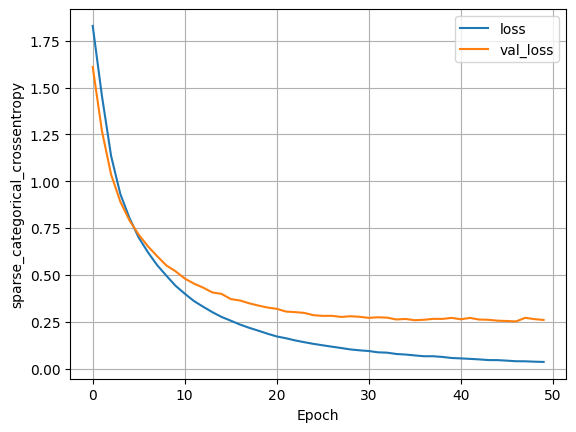

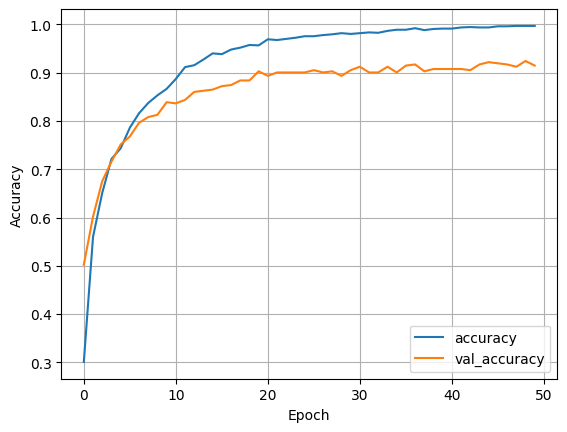

In [36]:
plot_loss(history)
plot_accuracy(history)

In [37]:
y_pred3 = nn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred3, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [38]:
y_pred

array([1, 0, 1, 6, 4, 2, 6, 4, 1, 5, 6, 4, 1, 4, 1, 0, 0, 5, 0, 6, 5, 6,
       3, 1, 0, 6, 5, 0, 2, 0, 2, 0, 1, 2, 4, 0, 5, 2, 5, 2, 4, 4, 5, 3,
       5, 0, 2, 2, 6, 5, 4, 4, 6, 6, 6, 3, 6, 1, 0, 2, 5, 5, 5, 5, 6, 5,
       4, 6, 6, 6, 1, 3, 4, 4, 1, 5, 5, 4, 0, 1, 3, 4, 2, 6, 6, 5, 5, 0,
       1, 3, 2, 3, 3, 4, 3, 0, 4, 0, 4, 3, 0, 1, 0, 2, 3, 0, 2, 5, 2, 3,
       2, 3, 4, 6, 2, 6, 3, 1, 6, 4, 6, 0, 5, 6, 6, 3, 6, 4, 4, 5, 2, 3,
       2, 4, 1, 6, 4, 2, 6, 6, 2, 4, 6, 0, 5, 4, 0, 0, 1, 6, 5, 5, 4, 5,
       4, 5, 2, 1, 4, 5, 5, 6, 0, 4, 3, 4, 0, 4, 4, 1, 1, 2, 3, 6, 6, 5,
       6, 4, 1, 5, 6, 6, 5, 1, 6, 2, 5, 5, 0, 5, 4, 4, 4, 4, 1, 5, 5, 5,
       3, 4, 4, 2, 6, 5, 4, 4, 3, 4, 2, 1, 3, 0, 2, 1, 4, 5, 5, 5, 3, 3,
       4, 1, 5, 0, 2, 3, 1, 0, 1, 2, 3, 1, 0, 2, 6, 2, 3, 3, 5, 2, 4, 0,
       2, 6, 4, 3, 3, 4, 0, 0, 3, 3, 4, 5, 3, 2, 5, 1, 0, 0, 4, 4, 5, 4,
       4, 2, 5, 1, 6, 0, 2, 1, 2, 4, 4, 3, 0, 5, 4, 4, 6, 0, 6, 4, 4, 1,
       0, 5, 5, 4, 5, 6, 0, 4, 5, 2, 2, 6, 2, 6, 0,

In [39]:
y_test


array([2, 0, 1, 6, 3, 2, 6, 4, 1, 5, 6, 4, 0, 4, 2, 0, 0, 5, 0, 6, 5, 6,
       3, 1, 1, 6, 5, 0, 2, 1, 2, 0, 2, 3, 4, 0, 5, 2, 5, 3, 4, 4, 5, 1,
       5, 0, 2, 2, 6, 5, 4, 4, 6, 6, 6, 3, 6, 0, 0, 2, 5, 5, 5, 1, 6, 5,
       4, 6, 6, 6, 1, 3, 4, 4, 2, 5, 5, 4, 1, 3, 3, 4, 3, 6, 6, 5, 5, 0,
       1, 1, 2, 3, 3, 4, 3, 0, 4, 0, 2, 3, 1, 1, 0, 2, 3, 1, 4, 5, 2, 3,
       2, 4, 4, 6, 2, 6, 3, 1, 6, 4, 6, 0, 5, 6, 6, 3, 6, 4, 4, 5, 1, 1,
       2, 4, 1, 6, 4, 4, 6, 6, 2, 4, 6, 0, 5, 4, 0, 0, 4, 6, 5, 5, 4, 5,
       0, 3, 2, 0, 4, 5, 5, 6, 0, 4, 3, 4, 0, 2, 4, 1, 1, 2, 3, 6, 6, 3,
       6, 4, 1, 5, 6, 6, 5, 1, 6, 4, 5, 5, 0, 5, 4, 4, 3, 4, 1, 5, 5, 5,
       3, 4, 4, 5, 6, 5, 4, 4, 3, 4, 0, 1, 3, 0, 2, 2, 4, 5, 3, 5, 4, 3,
       4, 1, 5, 0, 0, 3, 2, 0, 1, 3, 3, 1, 0, 2, 6, 1, 3, 3, 5, 2, 4, 0,
       3, 6, 4, 3, 3, 4, 0, 0, 3, 3, 4, 5, 1, 2, 5, 3, 0, 0, 4, 4, 5, 4,
       2, 2, 5, 1, 6, 0, 2, 4, 2, 4, 4, 3, 0, 5, 4, 4, 6, 0, 6, 1, 4, 1,
       0, 5, 5, 4, 5, 6, 1, 4, 5, 2, 3, 6, 2, 6, 0,

In [40]:
def plot_loss(history):
  fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
  fig.suptitle('Loss and Accuracy')
  ax1.plot(history.history['loss'], label='loss')
  ax1.plot(history.history['val_loss'], label='val_loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('sparse_categorical_crossentropy')
  ax1.grid(True)

  ax2.plot(history.history['accuracy'], label='accuracy')
  ax2.plot(history.history['val_accuracy'], label='val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.grid(True)

  plt.show()

In [41]:
#Grid Search methode
def train_model(X_train, y_train, num_node, dropout_prob, lr, batch_size, epochs):
  nn_model = tf.keras.Sequential([
      tf.keras.layers.Dense(num_node, activation='relu', input_shape=(15,)),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_node, activation='relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(7, activation='softmax')
  ])

  nn_model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  return nn_model, nn_model.fit( X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_valid, y_valid) , verbose=0)

32 nodes, dropout 0.0, lr 0.01, batch size 32


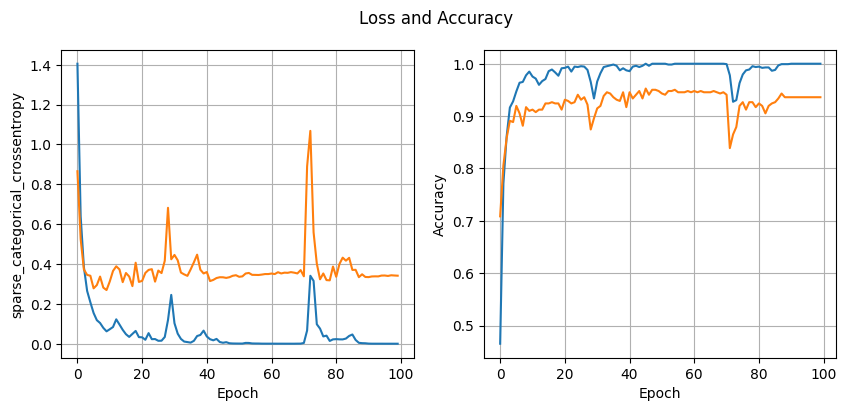

Validation accuracy: 0.9360189437866211, Validation loss: 0.3417232930660248
32 nodes, dropout 0.0, lr 0.01, batch size 64


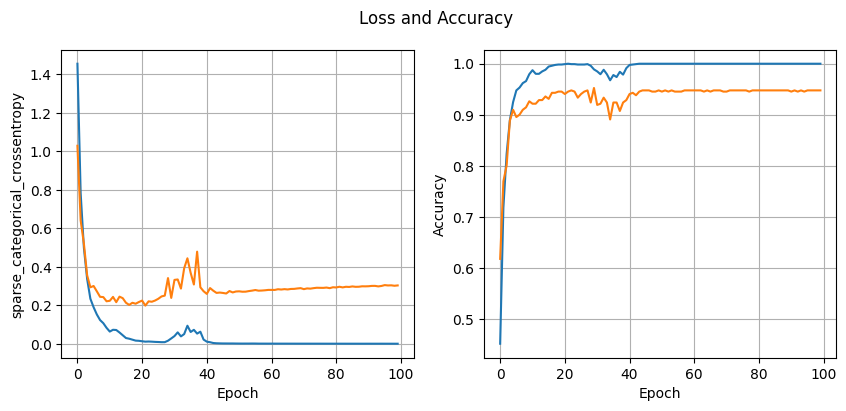

Validation accuracy: 0.9478672742843628, Validation loss: 0.30328652262687683
32 nodes, dropout 0.0, lr 0.01, batch size 128


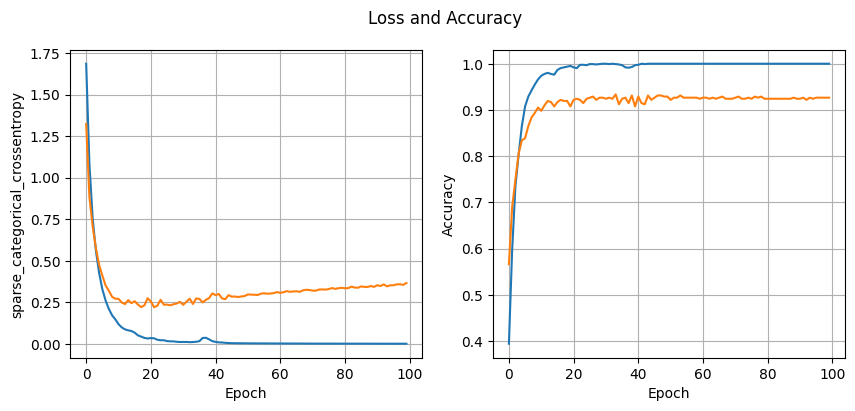

Validation accuracy: 0.9265402555465698, Validation loss: 0.36597537994384766
32 nodes, dropout 0.0, lr 0.005, batch size 32


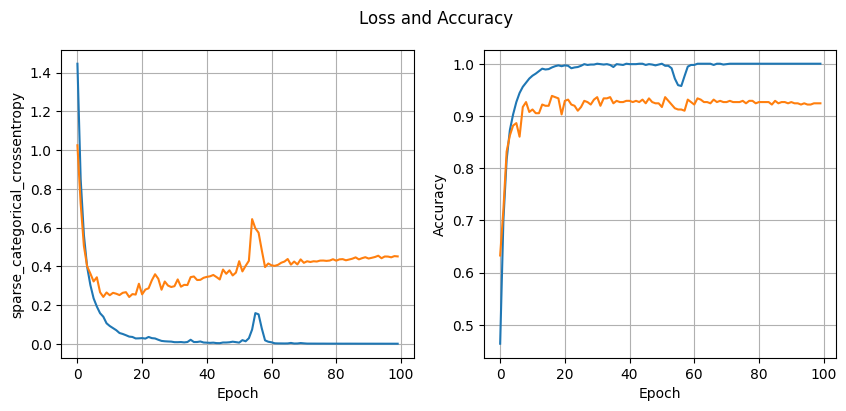

Validation accuracy: 0.9241706132888794, Validation loss: 0.4511326849460602
32 nodes, dropout 0.0, lr 0.005, batch size 64


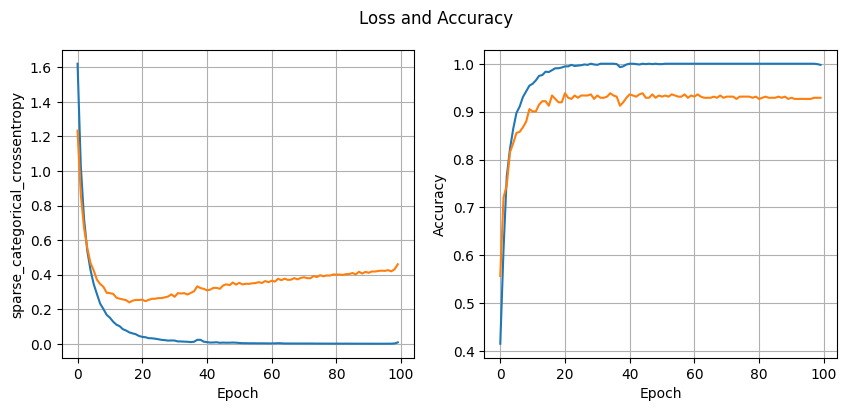

Validation accuracy: 0.928909957408905, Validation loss: 0.4604594111442566
32 nodes, dropout 0.0, lr 0.005, batch size 128


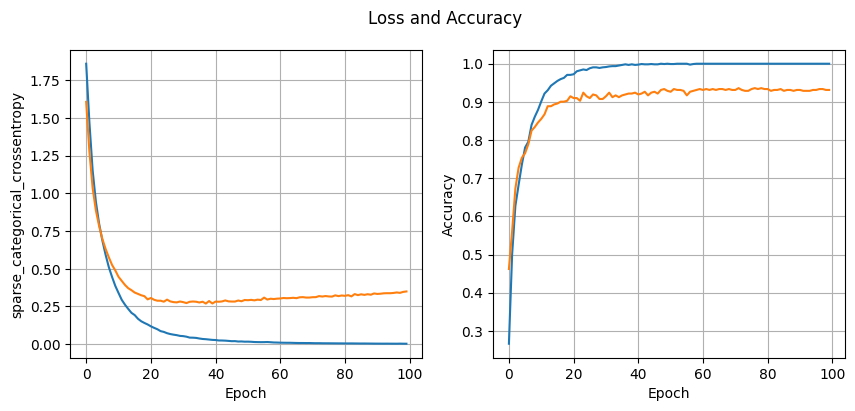

Validation accuracy: 0.9312795996665955, Validation loss: 0.34960323572158813
32 nodes, dropout 0.0, lr 0.001, batch size 32


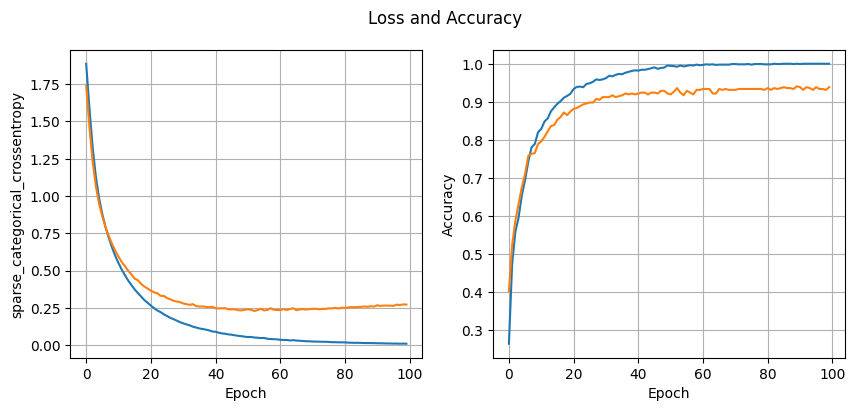

Validation accuracy: 0.9383886456489563, Validation loss: 0.27341240644454956
32 nodes, dropout 0.0, lr 0.001, batch size 64


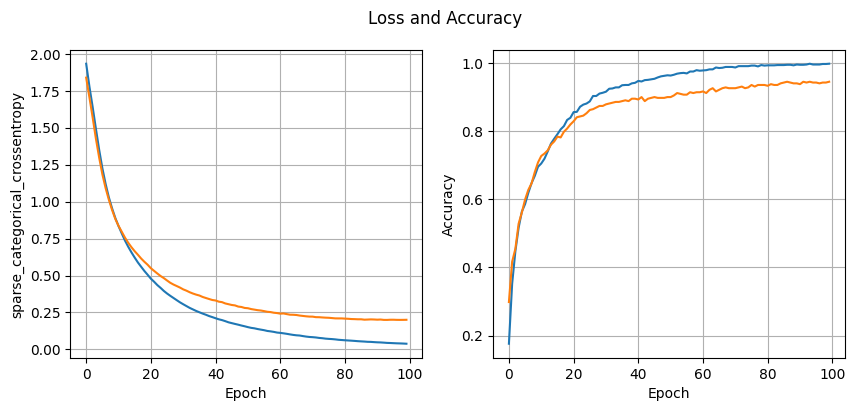

Validation accuracy: 0.9454976320266724, Validation loss: 0.20044071972370148
32 nodes, dropout 0.0, lr 0.001, batch size 128


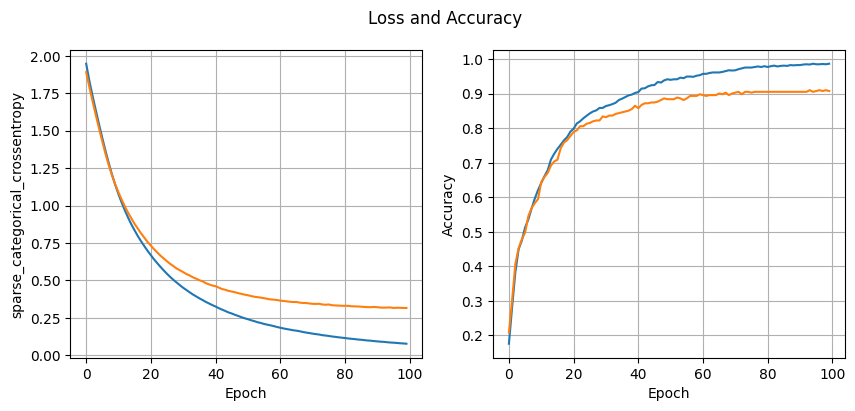

Validation accuracy: 0.9075829386711121, Validation loss: 0.316061794757843
32 nodes, dropout 0.1, lr 0.01, batch size 32


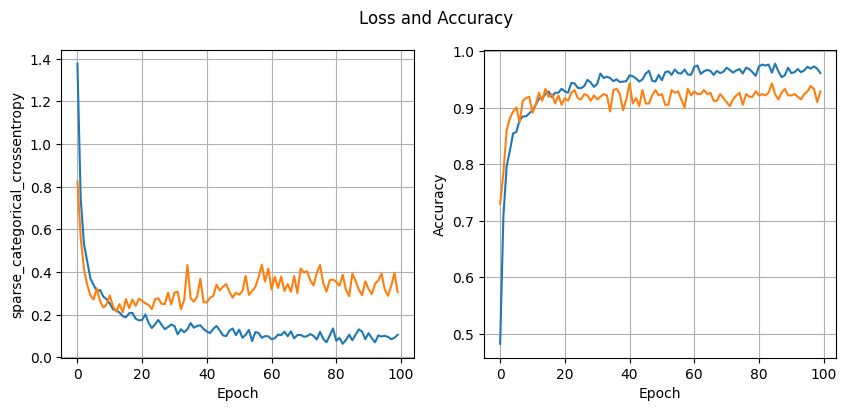

Validation accuracy: 0.928909957408905, Validation loss: 0.3064737617969513
32 nodes, dropout 0.1, lr 0.01, batch size 64


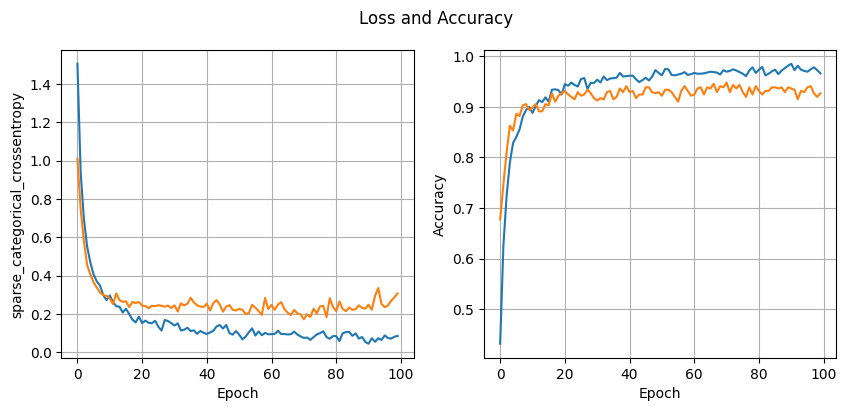

Validation accuracy: 0.9265402555465698, Validation loss: 0.3078943192958832
32 nodes, dropout 0.1, lr 0.01, batch size 128


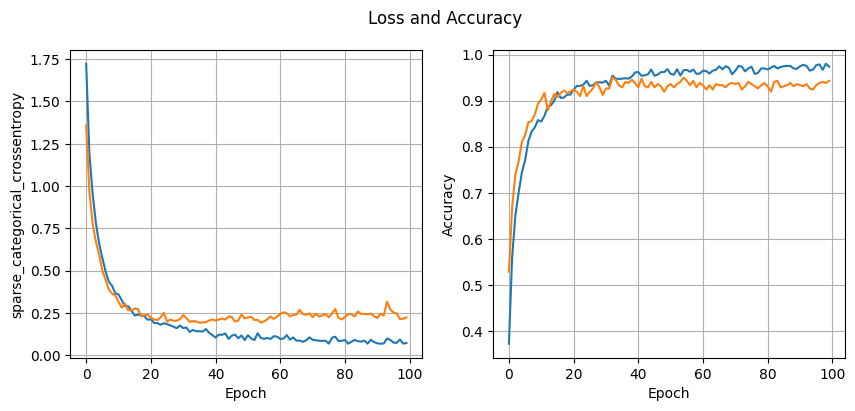

Validation accuracy: 0.9431279897689819, Validation loss: 0.2229713499546051
32 nodes, dropout 0.1, lr 0.005, batch size 32


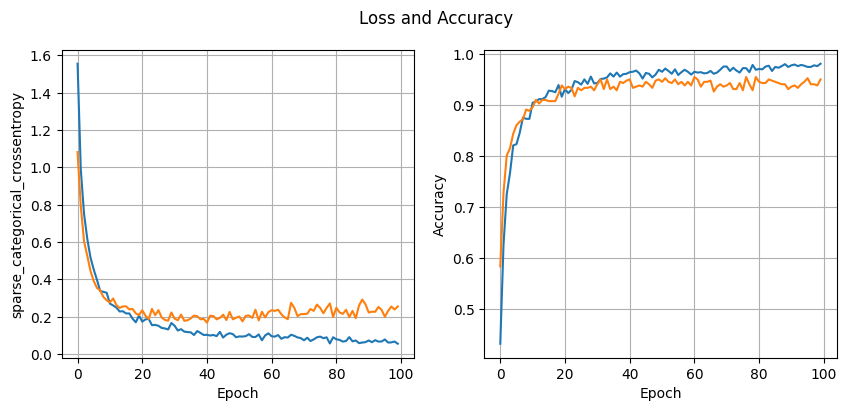

Validation accuracy: 0.950236976146698, Validation loss: 0.2550170421600342
32 nodes, dropout 0.1, lr 0.005, batch size 64


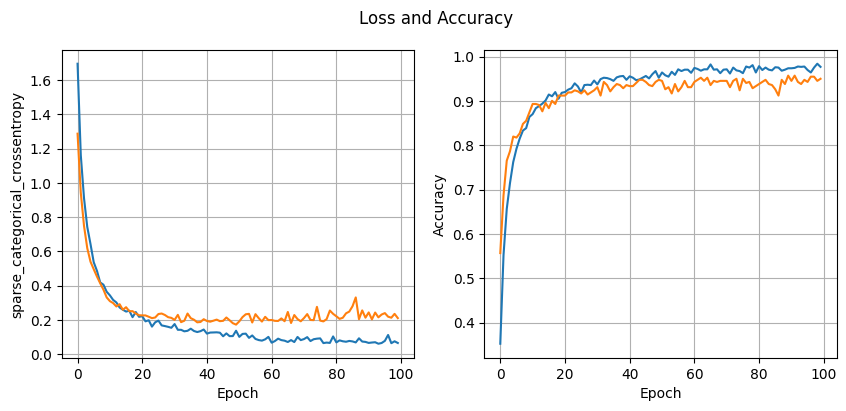

Validation accuracy: 0.950236976146698, Validation loss: 0.21047106385231018
32 nodes, dropout 0.1, lr 0.005, batch size 128


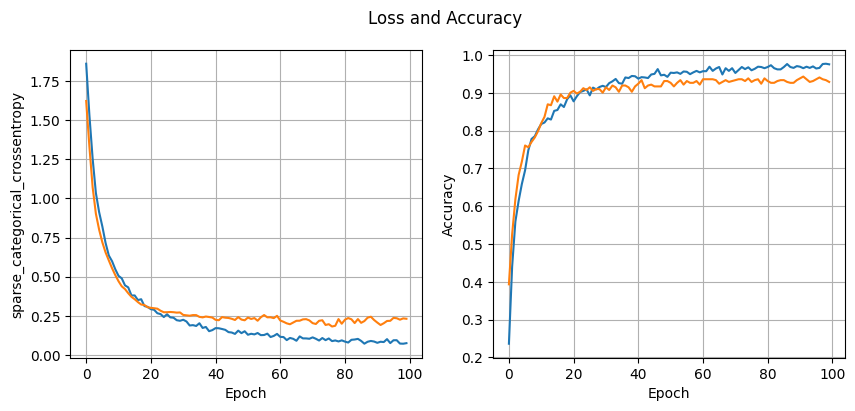

Validation accuracy: 0.928909957408905, Validation loss: 0.23088529706001282
32 nodes, dropout 0.1, lr 0.001, batch size 32


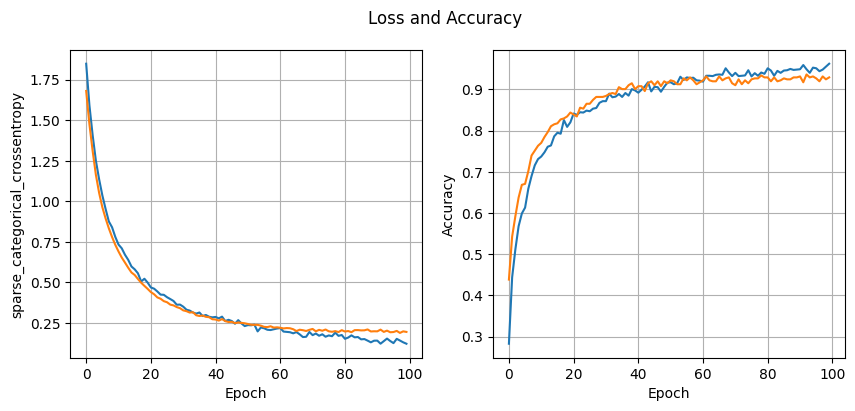

Validation accuracy: 0.928909957408905, Validation loss: 0.19527879357337952
32 nodes, dropout 0.1, lr 0.001, batch size 64


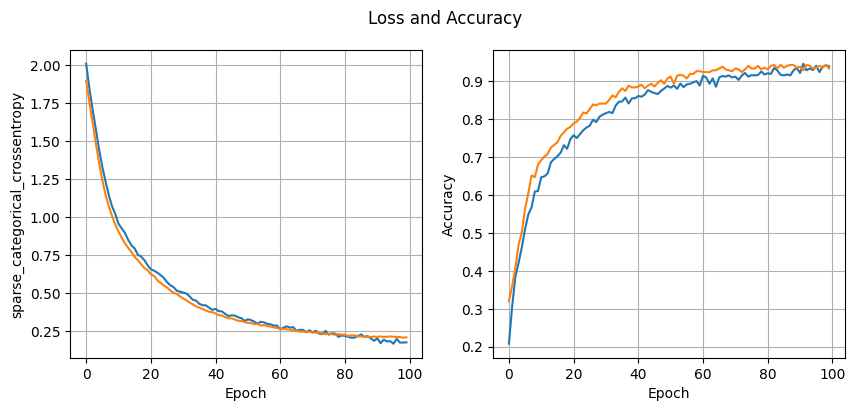

Validation accuracy: 0.9336493015289307, Validation loss: 0.20779792964458466
32 nodes, dropout 0.1, lr 0.001, batch size 128


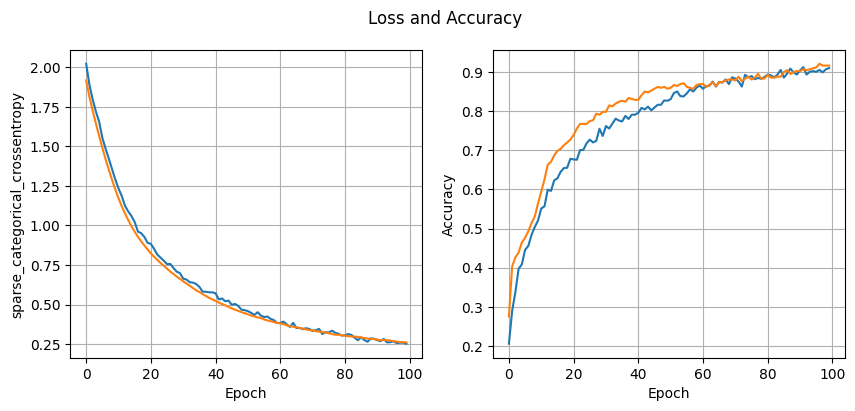

Validation accuracy: 0.9170616269111633, Validation loss: 0.2605927288532257
32 nodes, dropout 0.2, lr 0.01, batch size 32


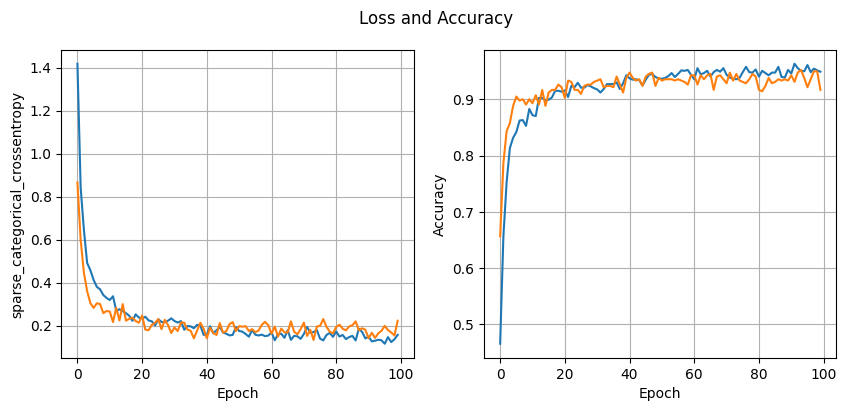

Validation accuracy: 0.9170616269111633, Validation loss: 0.22215212881565094
32 nodes, dropout 0.2, lr 0.01, batch size 64


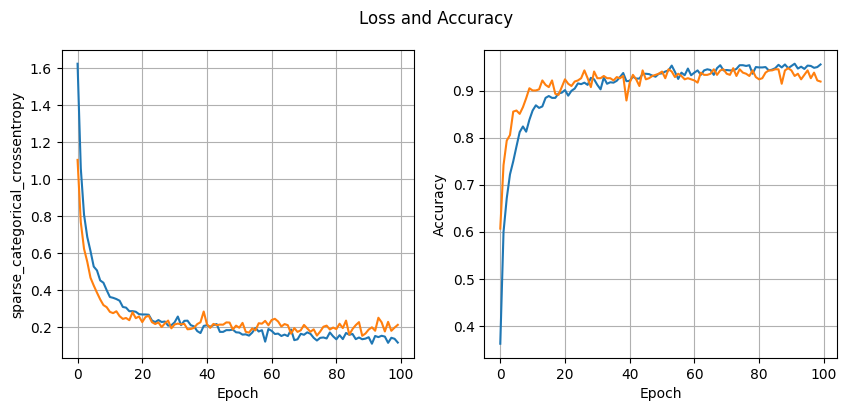

Validation accuracy: 0.9194312691688538, Validation loss: 0.2109285295009613
32 nodes, dropout 0.2, lr 0.01, batch size 128


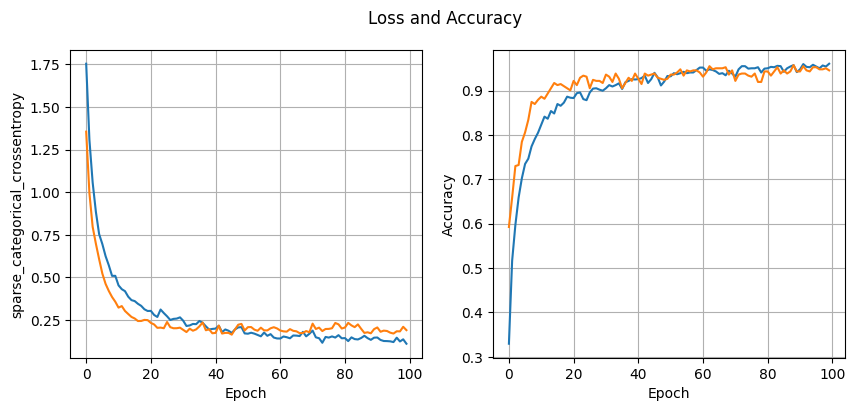

Validation accuracy: 0.9454976320266724, Validation loss: 0.18954195082187653
32 nodes, dropout 0.2, lr 0.005, batch size 32


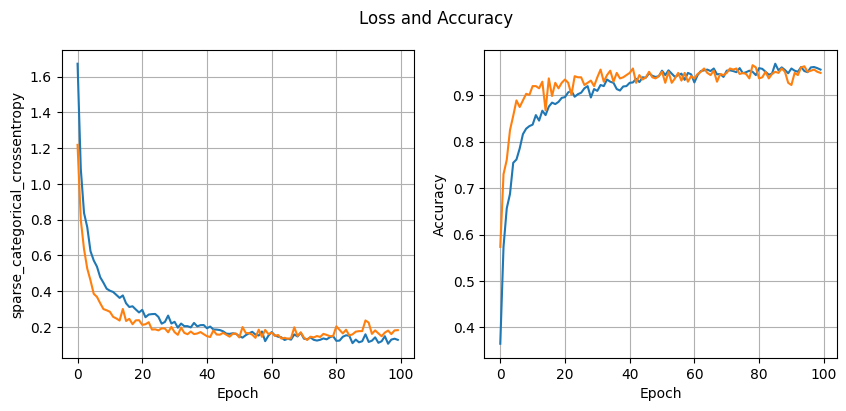

Validation accuracy: 0.9478672742843628, Validation loss: 0.18103520572185516
32 nodes, dropout 0.2, lr 0.005, batch size 64


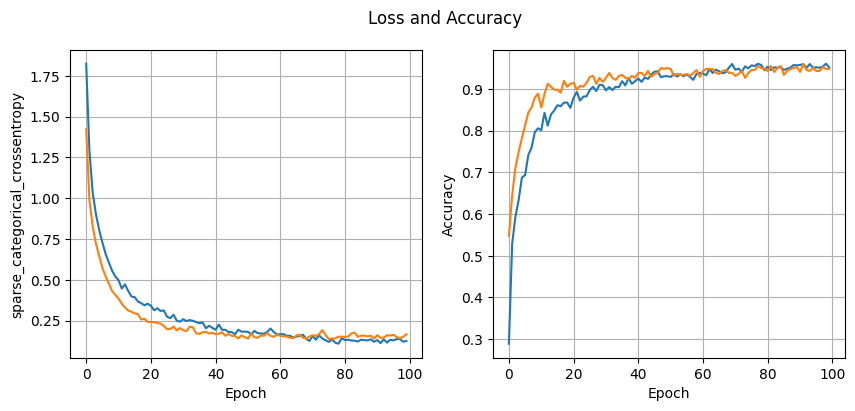

Validation accuracy: 0.9478672742843628, Validation loss: 0.16511580348014832
32 nodes, dropout 0.2, lr 0.005, batch size 128


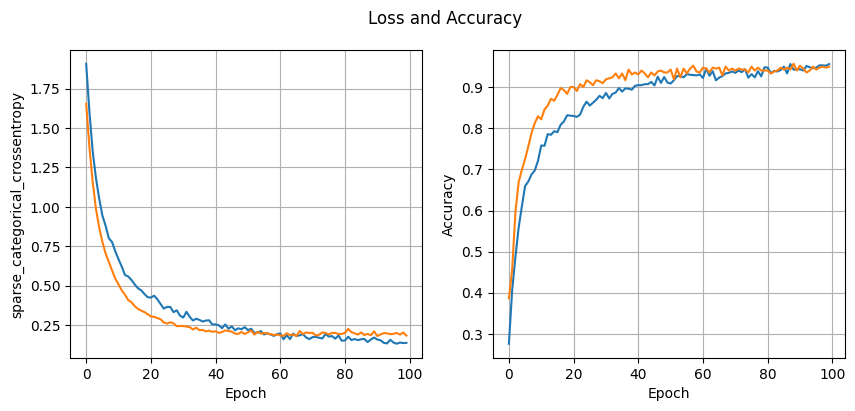

Validation accuracy: 0.950236976146698, Validation loss: 0.1821841597557068
32 nodes, dropout 0.2, lr 0.001, batch size 32


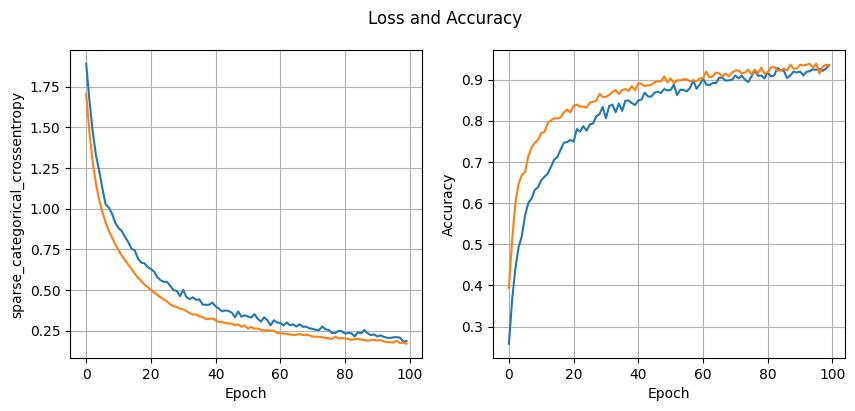

Validation accuracy: 0.9336493015289307, Validation loss: 0.16943983733654022
32 nodes, dropout 0.2, lr 0.001, batch size 64


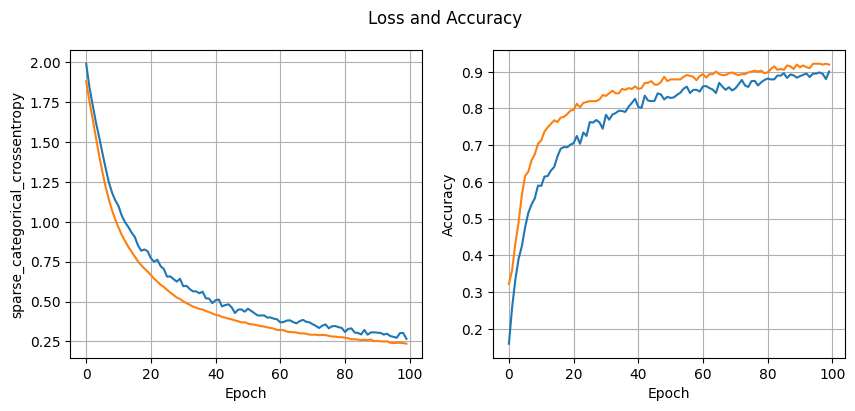

Validation accuracy: 0.9194312691688538, Validation loss: 0.23564301431179047
32 nodes, dropout 0.2, lr 0.001, batch size 128


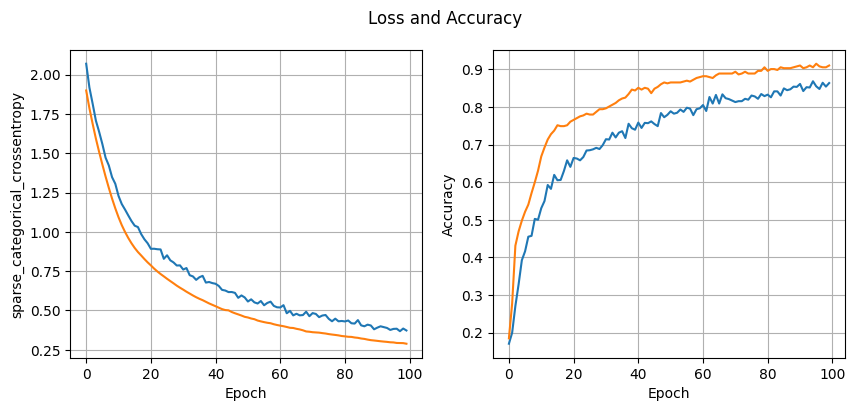

Validation accuracy: 0.9099525809288025, Validation loss: 0.28862375020980835
64 nodes, dropout 0.0, lr 0.01, batch size 32


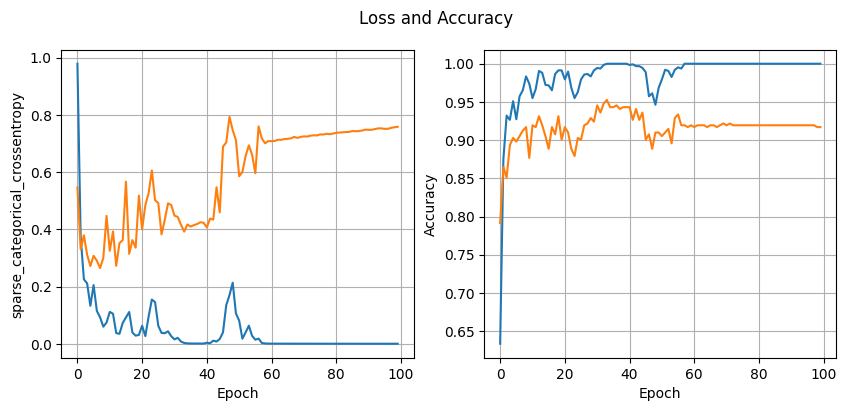

Validation accuracy: 0.9170616269111633, Validation loss: 0.7581097483634949
64 nodes, dropout 0.0, lr 0.01, batch size 64


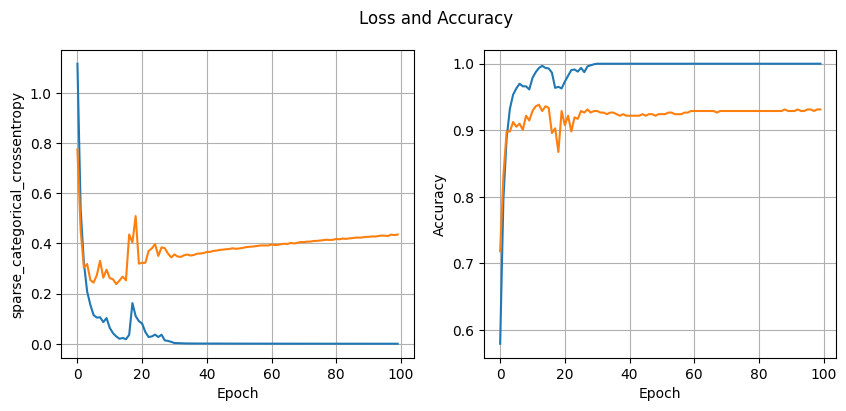

Validation accuracy: 0.9312795996665955, Validation loss: 0.43576478958129883
64 nodes, dropout 0.0, lr 0.01, batch size 128


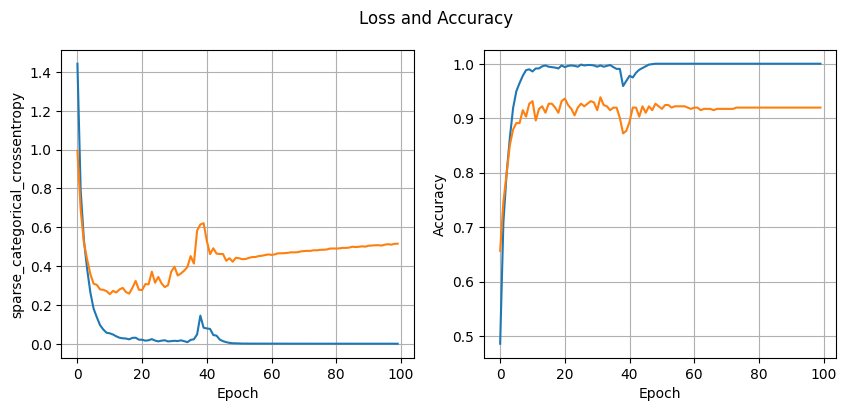

Validation accuracy: 0.9194312691688538, Validation loss: 0.5154728889465332
64 nodes, dropout 0.0, lr 0.005, batch size 32


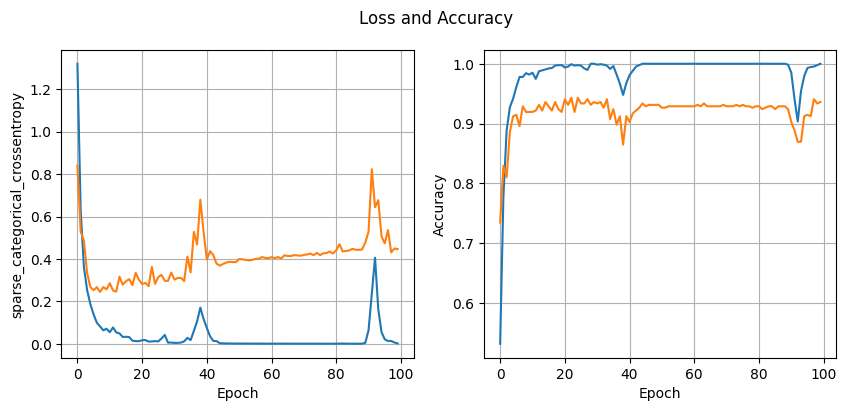

Validation accuracy: 0.9360189437866211, Validation loss: 0.44645246863365173
64 nodes, dropout 0.0, lr 0.005, batch size 64


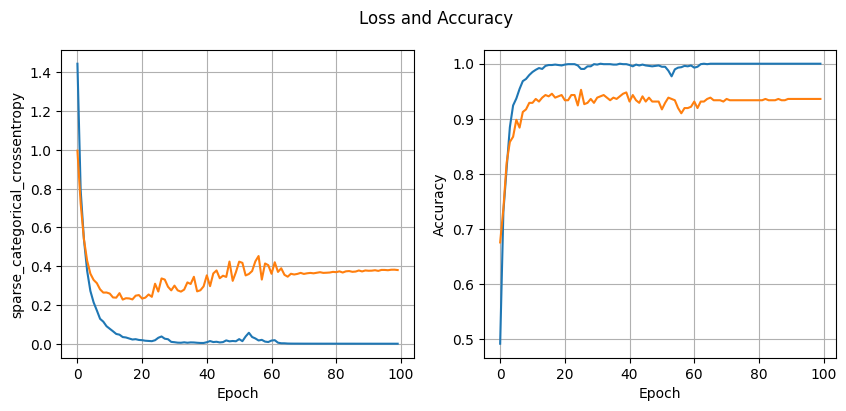

Validation accuracy: 0.9360189437866211, Validation loss: 0.38045549392700195
64 nodes, dropout 0.0, lr 0.005, batch size 128


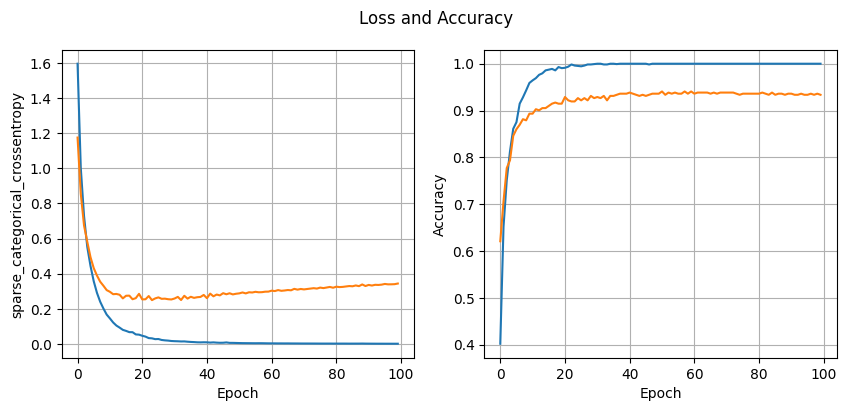

Validation accuracy: 0.9336493015289307, Validation loss: 0.3437182605266571
64 nodes, dropout 0.0, lr 0.001, batch size 32


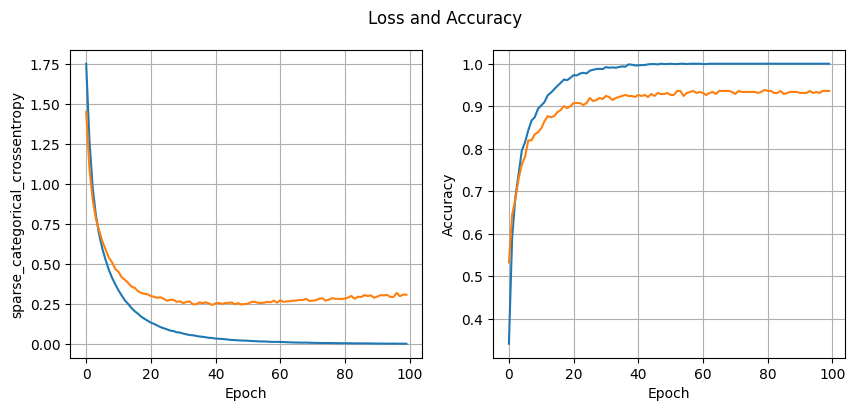

Validation accuracy: 0.9360189437866211, Validation loss: 0.30933645367622375
64 nodes, dropout 0.0, lr 0.001, batch size 64


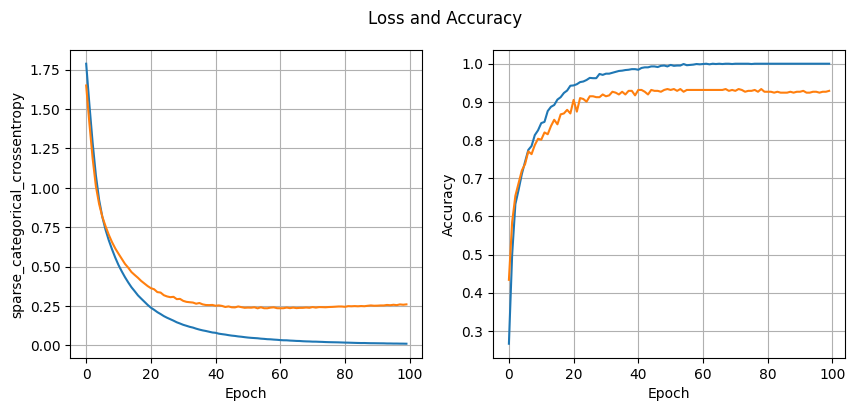

Validation accuracy: 0.928909957408905, Validation loss: 0.2596038579940796
64 nodes, dropout 0.0, lr 0.001, batch size 128


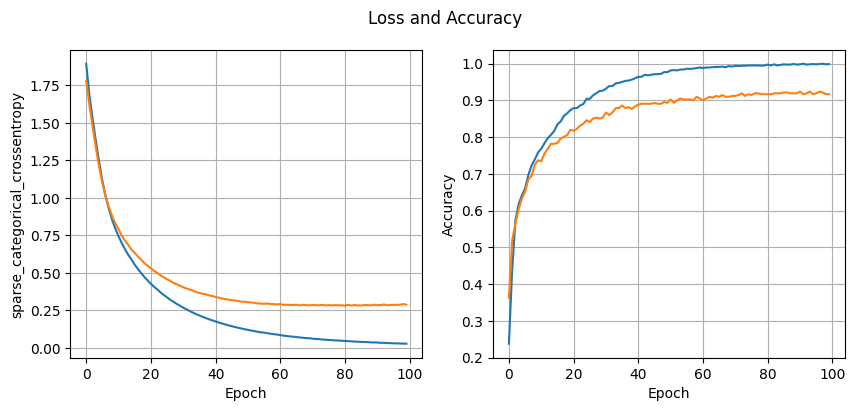

Validation accuracy: 0.9170616269111633, Validation loss: 0.28830432891845703
64 nodes, dropout 0.1, lr 0.01, batch size 32


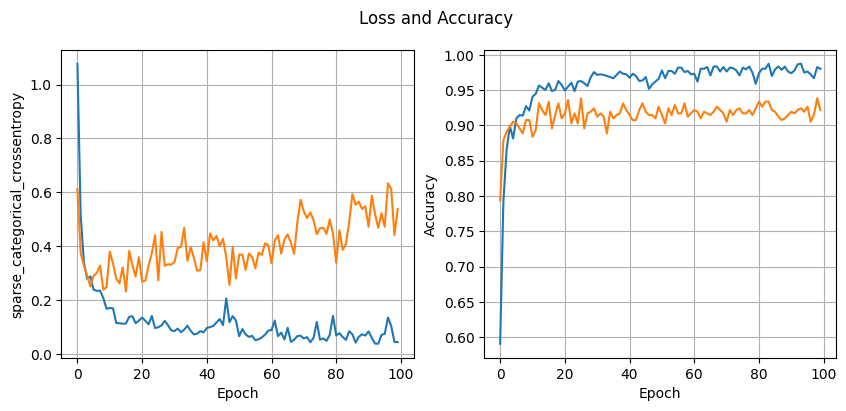

Validation accuracy: 0.921800971031189, Validation loss: 0.5378636121749878
64 nodes, dropout 0.1, lr 0.01, batch size 64


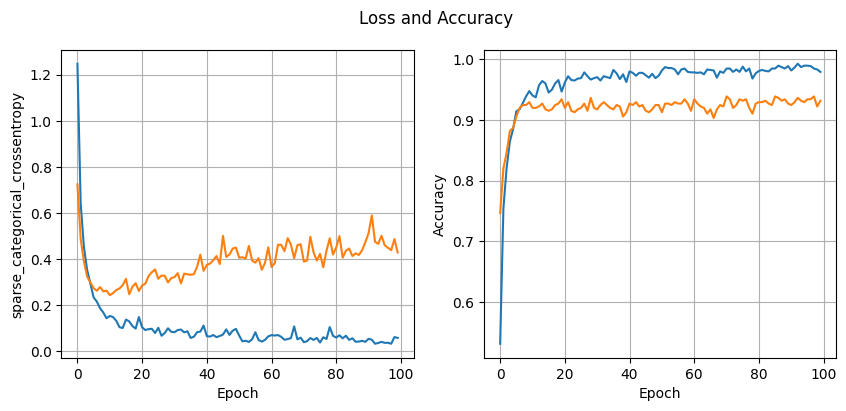

Validation accuracy: 0.9312795996665955, Validation loss: 0.4280604124069214
64 nodes, dropout 0.1, lr 0.01, batch size 128


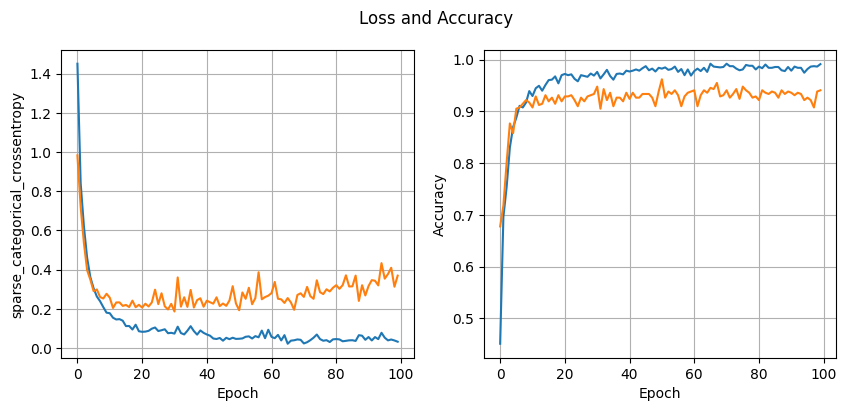

Validation accuracy: 0.9407582879066467, Validation loss: 0.36913448572158813
64 nodes, dropout 0.1, lr 0.005, batch size 32


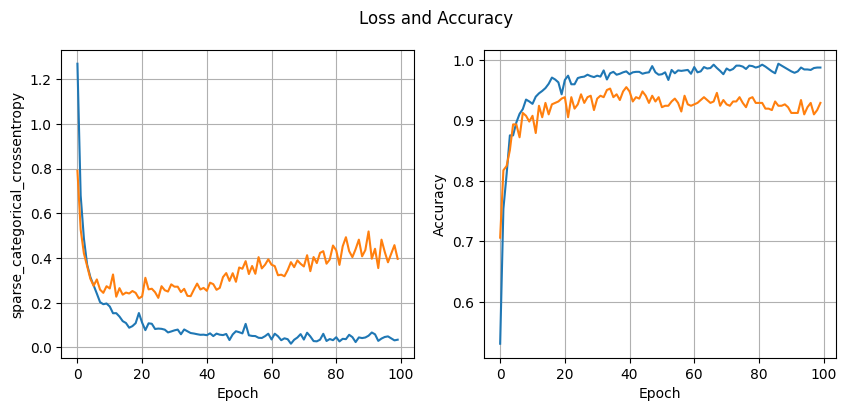

Validation accuracy: 0.928909957408905, Validation loss: 0.39606794714927673
64 nodes, dropout 0.1, lr 0.005, batch size 64


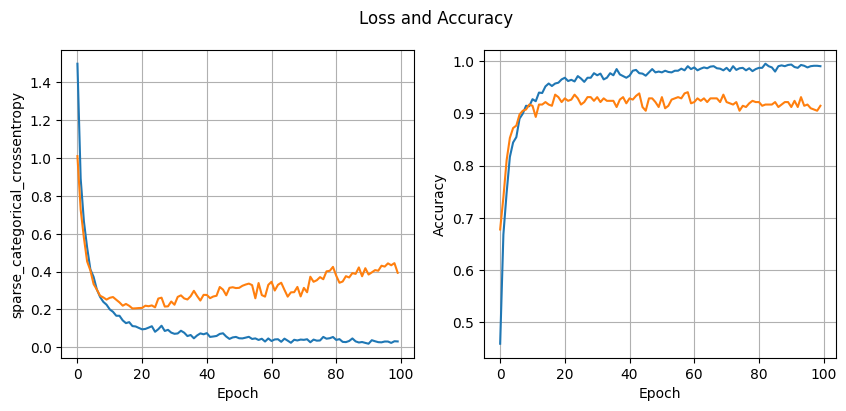

Validation accuracy: 0.9146919250488281, Validation loss: 0.3940070867538452
64 nodes, dropout 0.1, lr 0.005, batch size 128


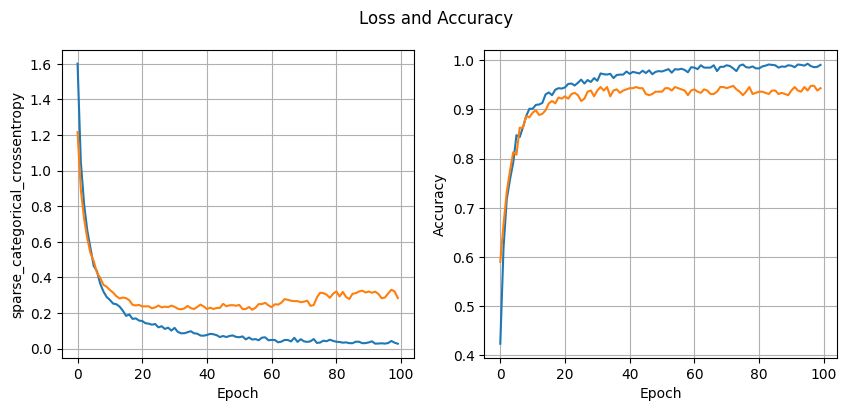

Validation accuracy: 0.9431279897689819, Validation loss: 0.28369009494781494
64 nodes, dropout 0.1, lr 0.001, batch size 32


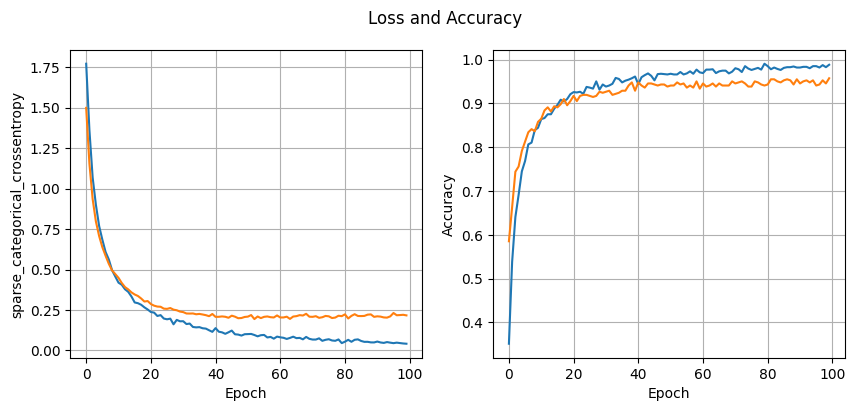

Validation accuracy: 0.9573459625244141, Validation loss: 0.2165575921535492
64 nodes, dropout 0.1, lr 0.001, batch size 64


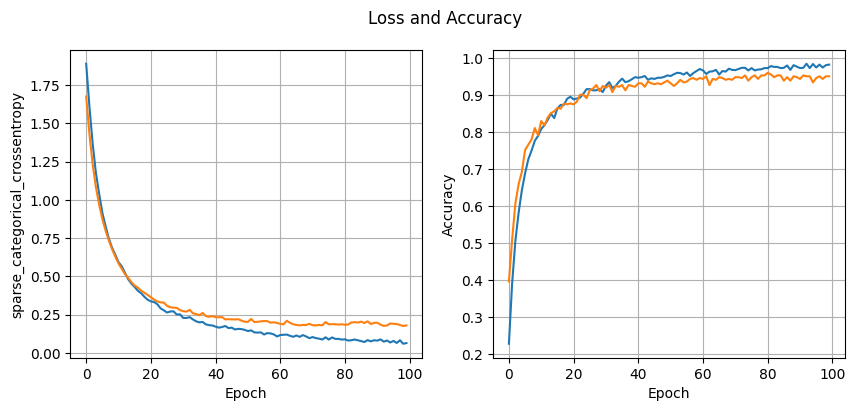

Validation accuracy: 0.950236976146698, Validation loss: 0.17867286503314972
64 nodes, dropout 0.1, lr 0.001, batch size 128


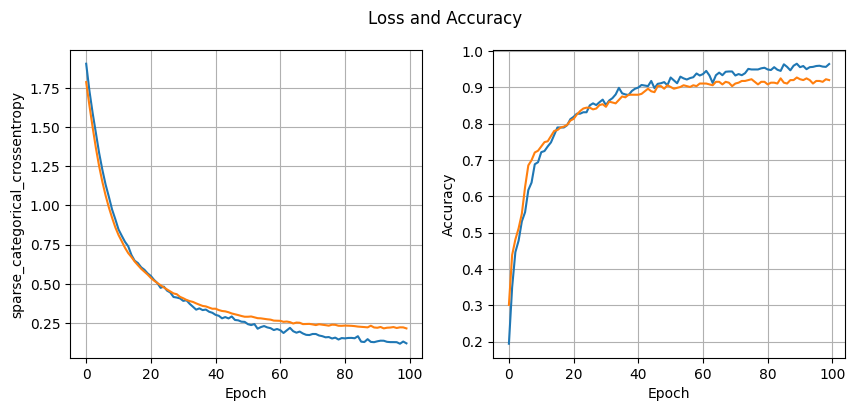

Validation accuracy: 0.9194312691688538, Validation loss: 0.21610769629478455
64 nodes, dropout 0.2, lr 0.01, batch size 32


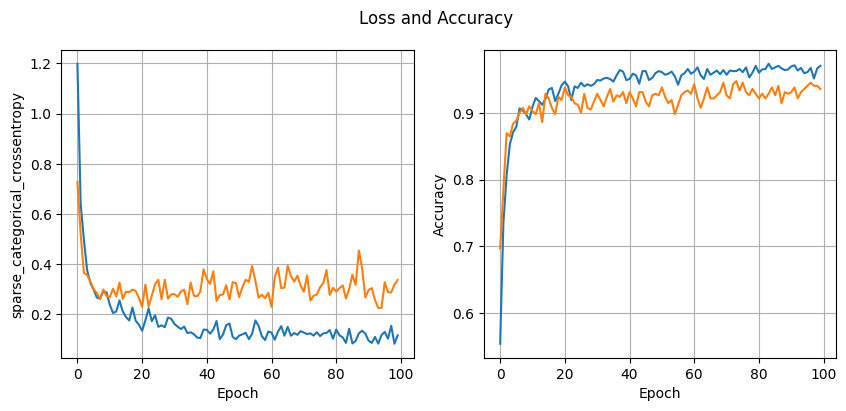

Validation accuracy: 0.9360189437866211, Validation loss: 0.33718571066856384
64 nodes, dropout 0.2, lr 0.01, batch size 64


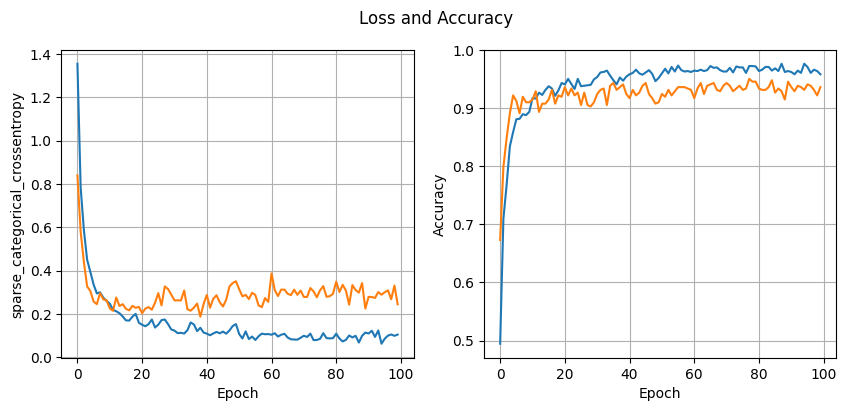

Validation accuracy: 0.9360189437866211, Validation loss: 0.24441921710968018
64 nodes, dropout 0.2, lr 0.01, batch size 128


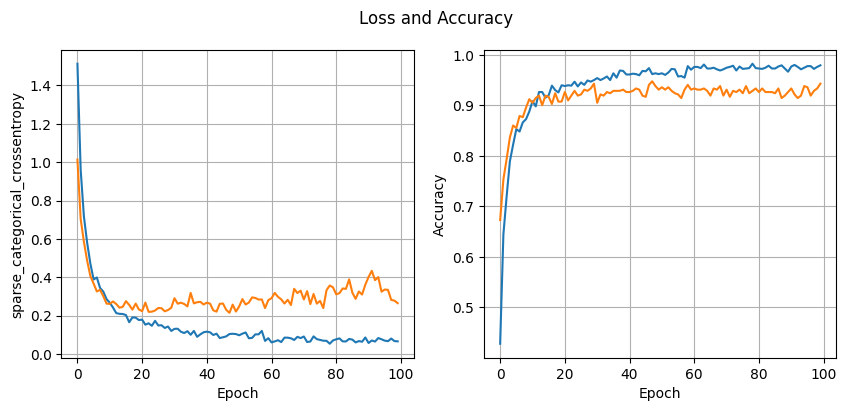

Validation accuracy: 0.9431279897689819, Validation loss: 0.264560341835022
64 nodes, dropout 0.2, lr 0.005, batch size 32


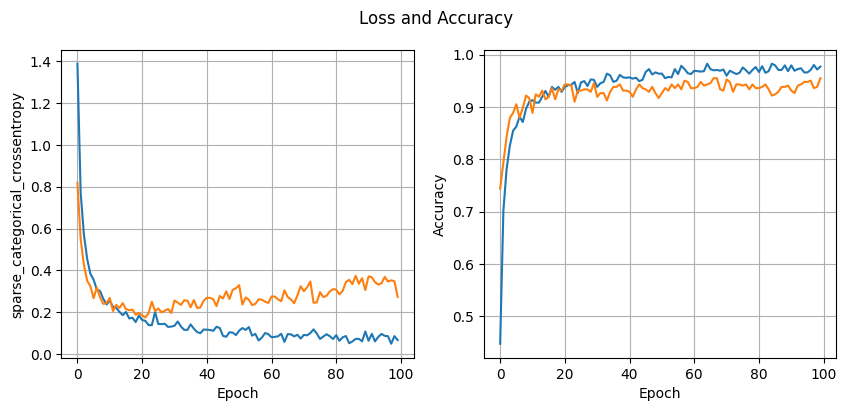

Validation accuracy: 0.9549763202667236, Validation loss: 0.2732377350330353
64 nodes, dropout 0.2, lr 0.005, batch size 64


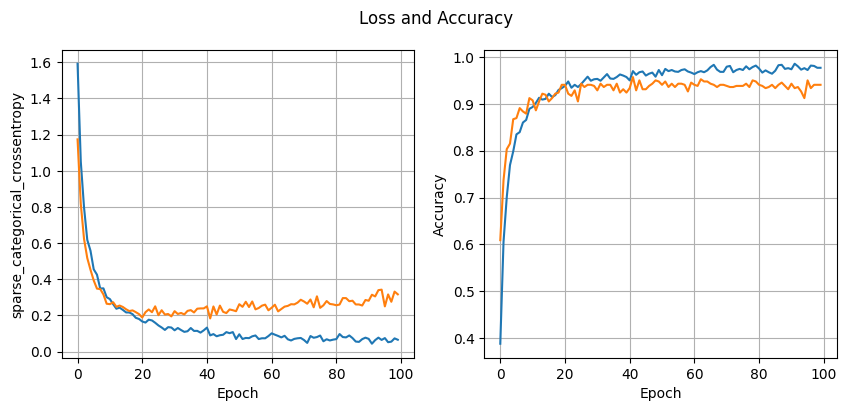

Validation accuracy: 0.9407582879066467, Validation loss: 0.3164060115814209
64 nodes, dropout 0.2, lr 0.005, batch size 128


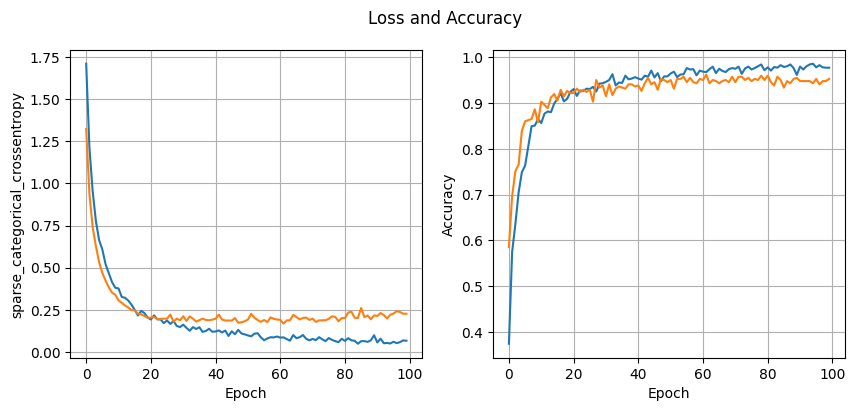

Validation accuracy: 0.9526066184043884, Validation loss: 0.22713476419448853
64 nodes, dropout 0.2, lr 0.001, batch size 32


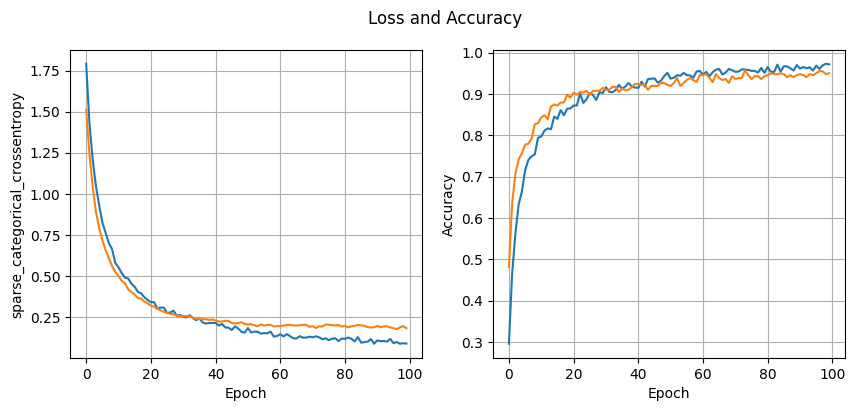

Validation accuracy: 0.950236976146698, Validation loss: 0.18096989393234253
64 nodes, dropout 0.2, lr 0.001, batch size 64


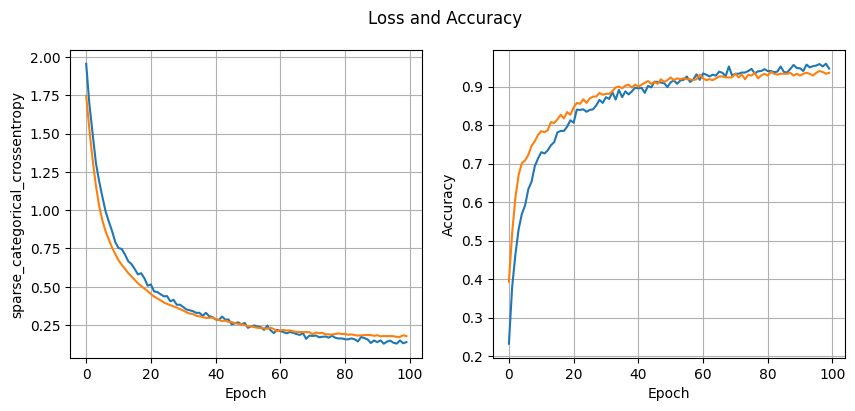

Validation accuracy: 0.9360189437866211, Validation loss: 0.17745062708854675
64 nodes, dropout 0.2, lr 0.001, batch size 128


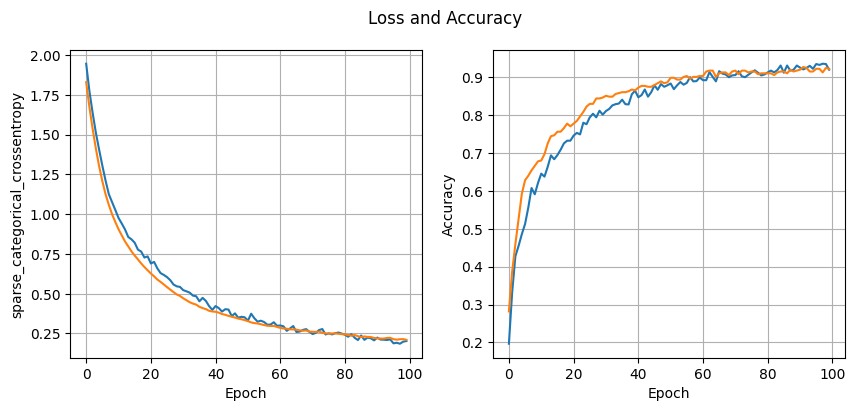

Validation accuracy: 0.921800971031189, Validation loss: 0.21029342710971832
164 nodes, dropout 0.0, lr 0.01, batch size 32


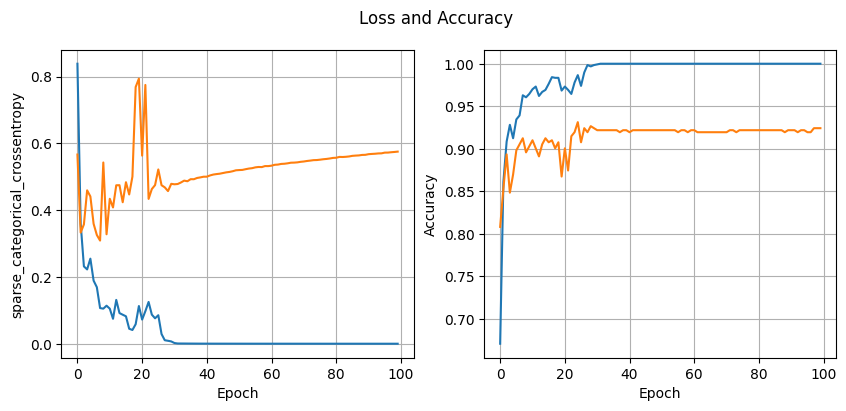

Validation accuracy: 0.9241706132888794, Validation loss: 0.5752428770065308
164 nodes, dropout 0.0, lr 0.01, batch size 64


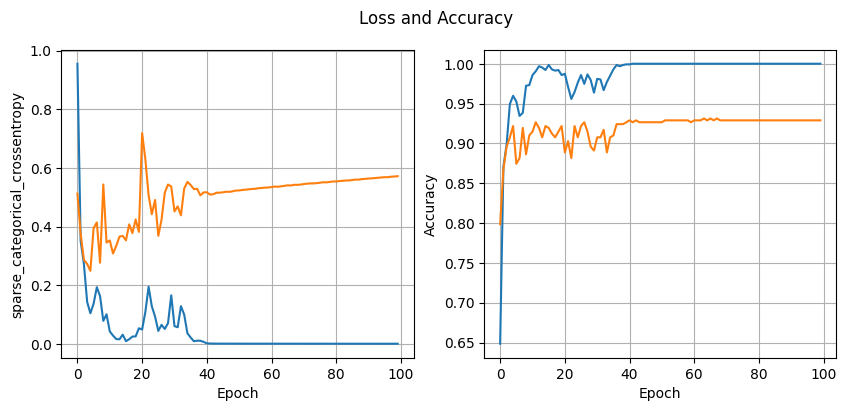

Validation accuracy: 0.928909957408905, Validation loss: 0.5717463493347168
164 nodes, dropout 0.0, lr 0.01, batch size 128


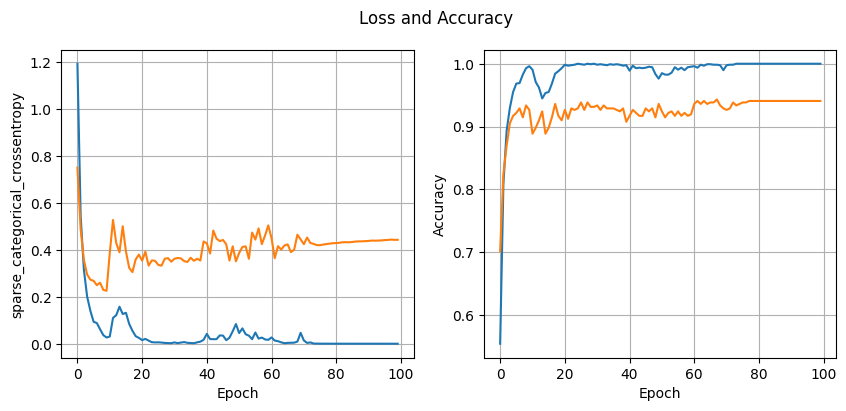

Validation accuracy: 0.9407582879066467, Validation loss: 0.44244611263275146
164 nodes, dropout 0.0, lr 0.005, batch size 32


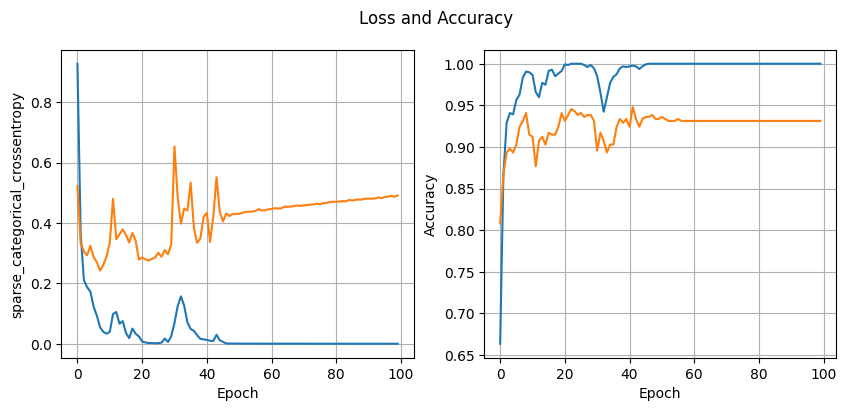

Validation accuracy: 0.9312795996665955, Validation loss: 0.49111679196357727
164 nodes, dropout 0.0, lr 0.005, batch size 64


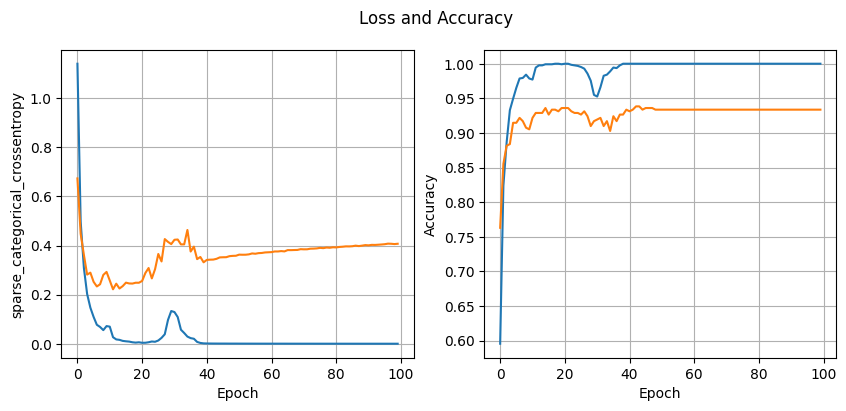

Validation accuracy: 0.9336493015289307, Validation loss: 0.40737712383270264
164 nodes, dropout 0.0, lr 0.005, batch size 128


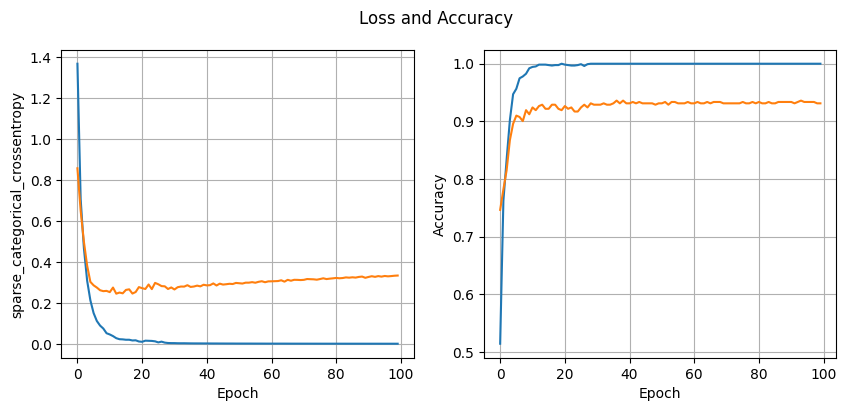

Validation accuracy: 0.9312795996665955, Validation loss: 0.3333779275417328
164 nodes, dropout 0.0, lr 0.001, batch size 32


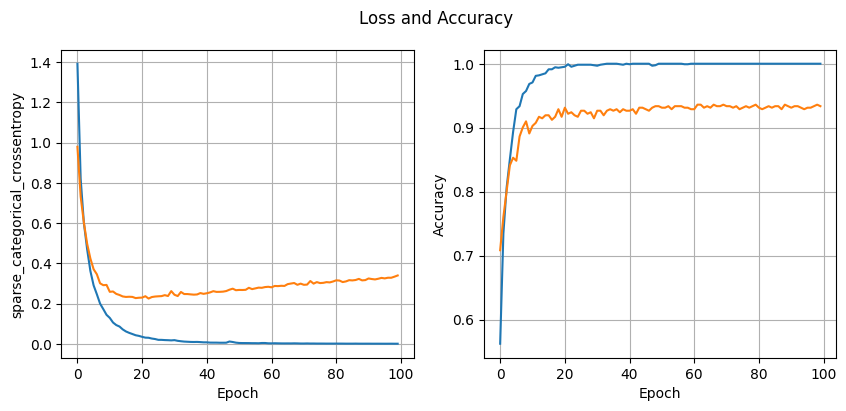

Validation accuracy: 0.9336493015289307, Validation loss: 0.33976036310195923
164 nodes, dropout 0.0, lr 0.001, batch size 64


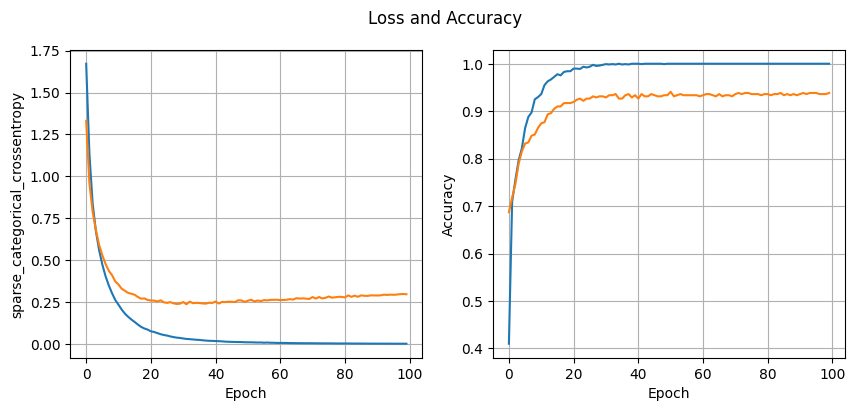

Validation accuracy: 0.9383886456489563, Validation loss: 0.2971358895301819
164 nodes, dropout 0.0, lr 0.001, batch size 128


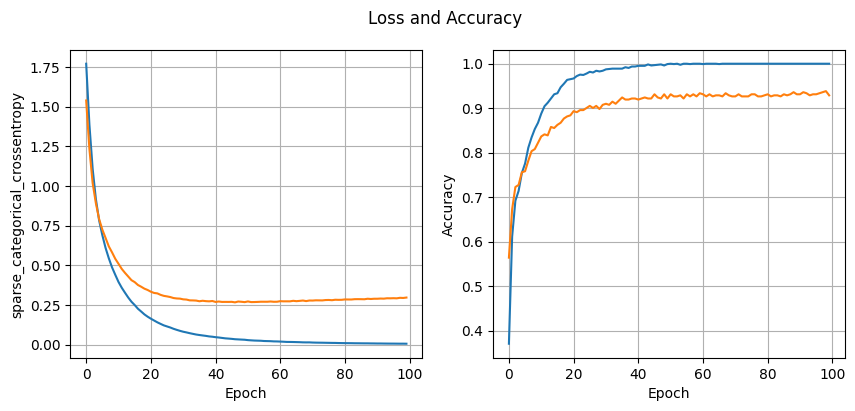

Validation accuracy: 0.928909957408905, Validation loss: 0.2968630790710449
164 nodes, dropout 0.1, lr 0.01, batch size 32


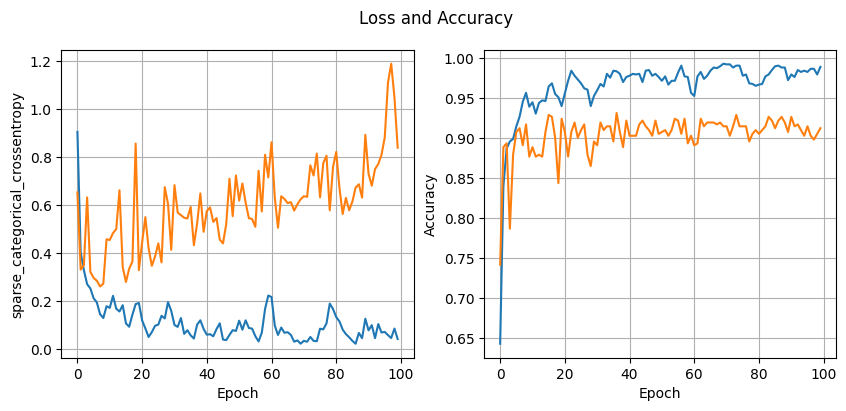

Validation accuracy: 0.9123222827911377, Validation loss: 0.8392903208732605
164 nodes, dropout 0.1, lr 0.01, batch size 64


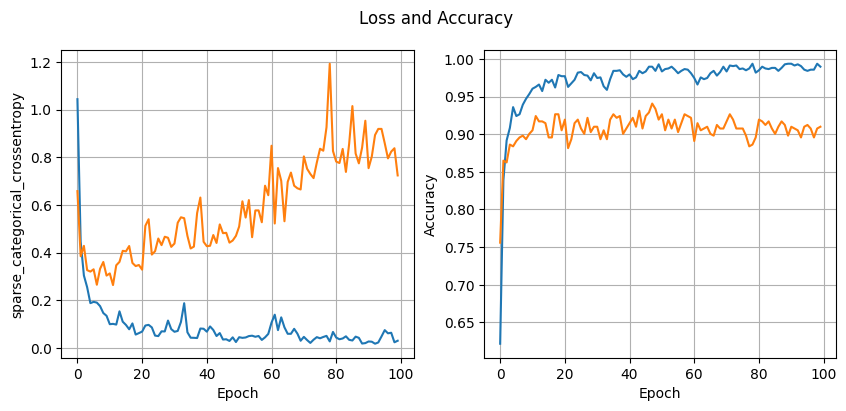

Validation accuracy: 0.9099525809288025, Validation loss: 0.724284827709198
164 nodes, dropout 0.1, lr 0.01, batch size 128


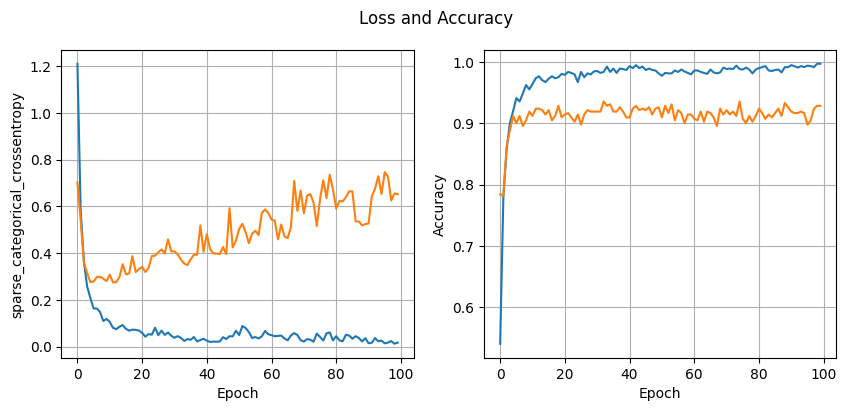

Validation accuracy: 0.928909957408905, Validation loss: 0.652392566204071
164 nodes, dropout 0.1, lr 0.005, batch size 32


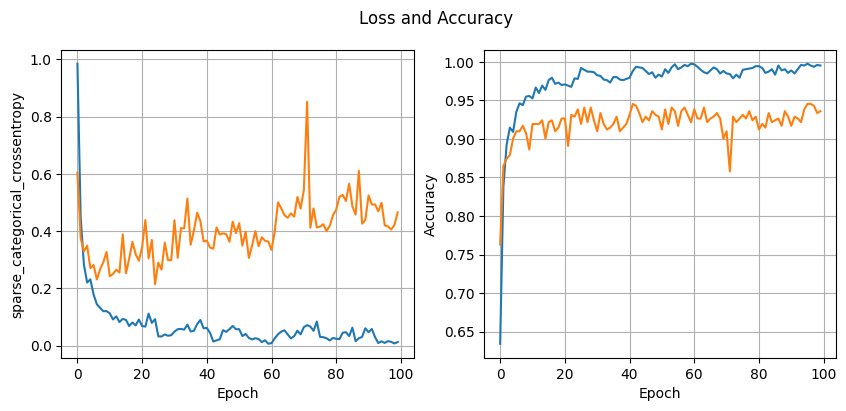

Validation accuracy: 0.9360189437866211, Validation loss: 0.4653180241584778
164 nodes, dropout 0.1, lr 0.005, batch size 64


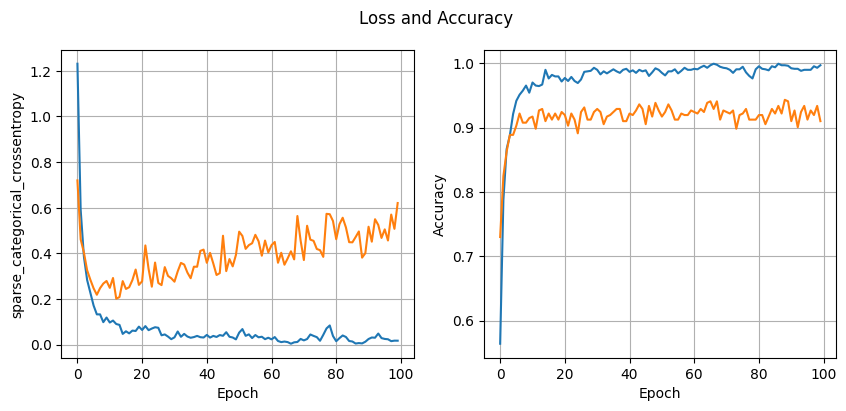

Validation accuracy: 0.9099525809288025, Validation loss: 0.620697021484375
164 nodes, dropout 0.1, lr 0.005, batch size 128


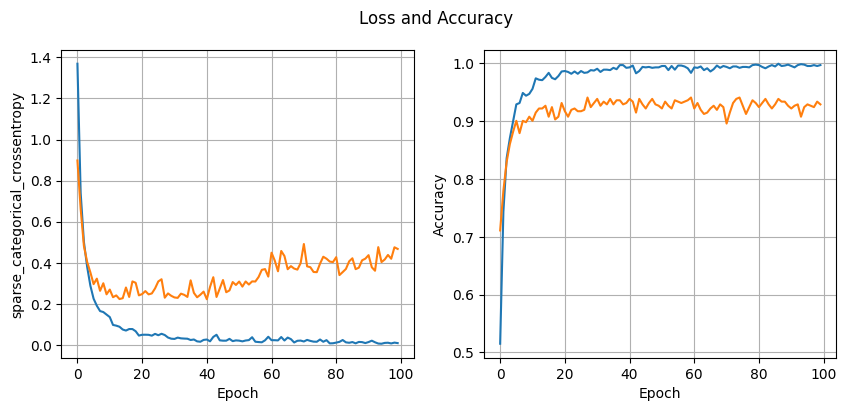

Validation accuracy: 0.928909957408905, Validation loss: 0.46762630343437195
164 nodes, dropout 0.1, lr 0.001, batch size 32


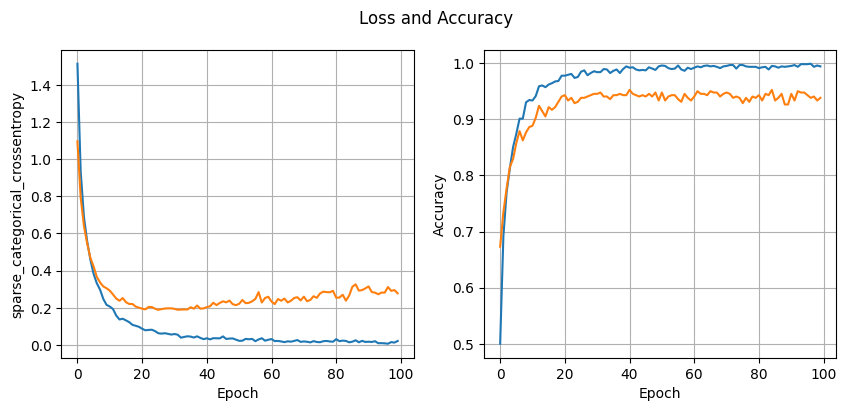

Validation accuracy: 0.9383886456489563, Validation loss: 0.2776477634906769
164 nodes, dropout 0.1, lr 0.001, batch size 64


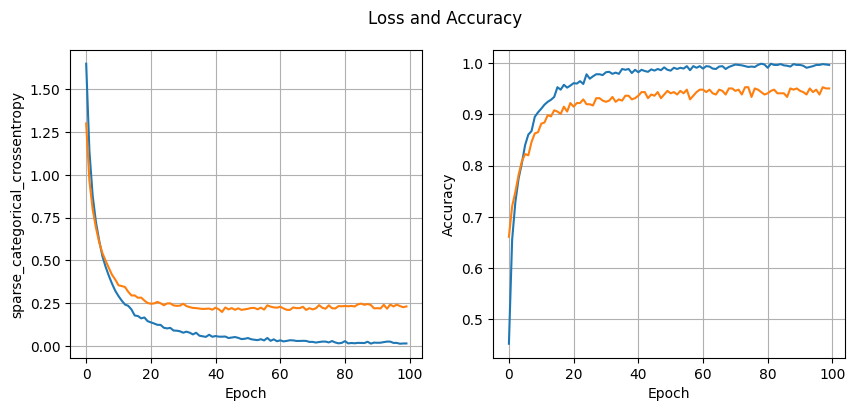

Validation accuracy: 0.950236976146698, Validation loss: 0.23109042644500732
164 nodes, dropout 0.1, lr 0.001, batch size 128


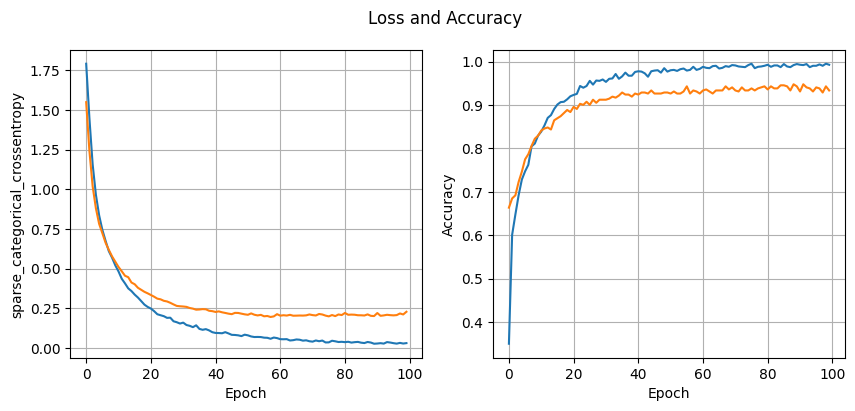

Validation accuracy: 0.9336493015289307, Validation loss: 0.22872263193130493
164 nodes, dropout 0.2, lr 0.01, batch size 32


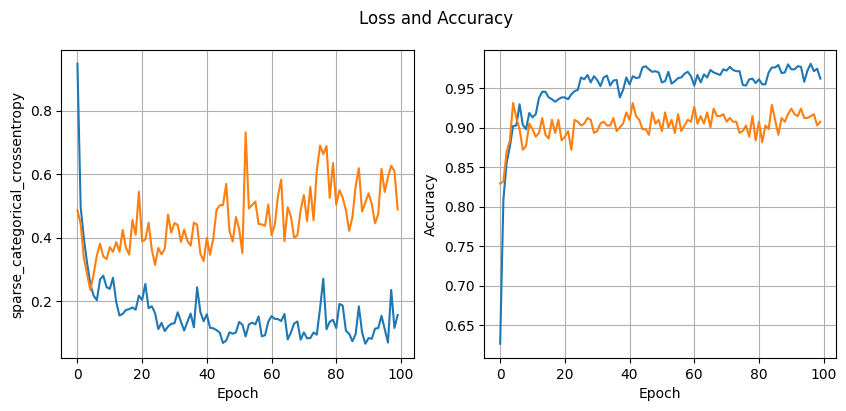

Validation accuracy: 0.9075829386711121, Validation loss: 0.4886082410812378
164 nodes, dropout 0.2, lr 0.01, batch size 64


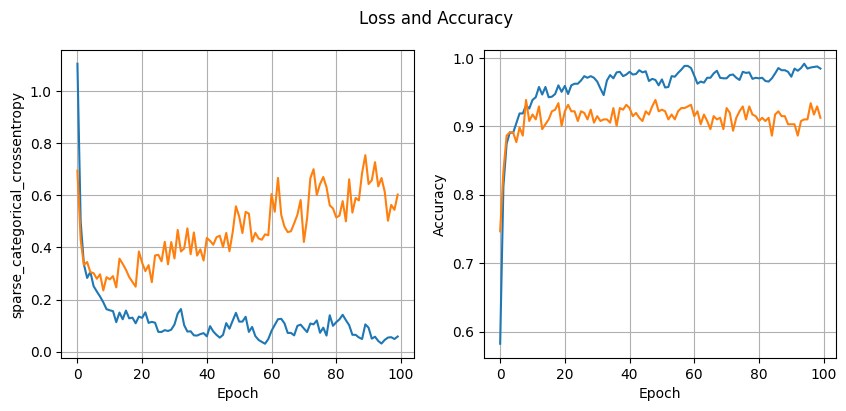

Validation accuracy: 0.9123222827911377, Validation loss: 0.6022319197654724
164 nodes, dropout 0.2, lr 0.01, batch size 128


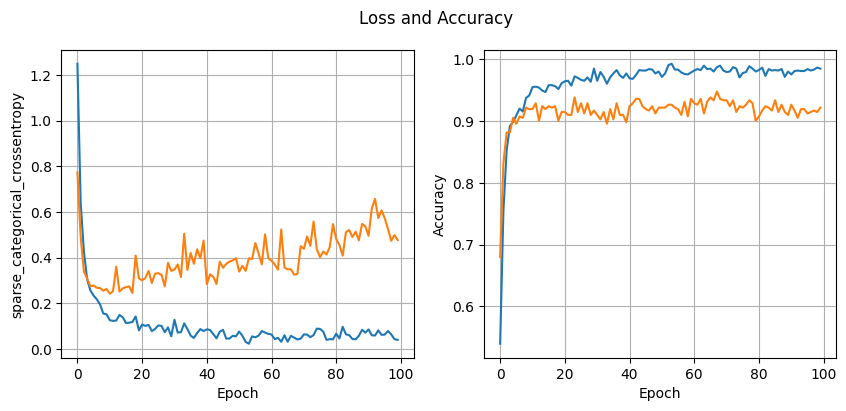

Validation accuracy: 0.921800971031189, Validation loss: 0.4767877757549286
164 nodes, dropout 0.2, lr 0.005, batch size 32


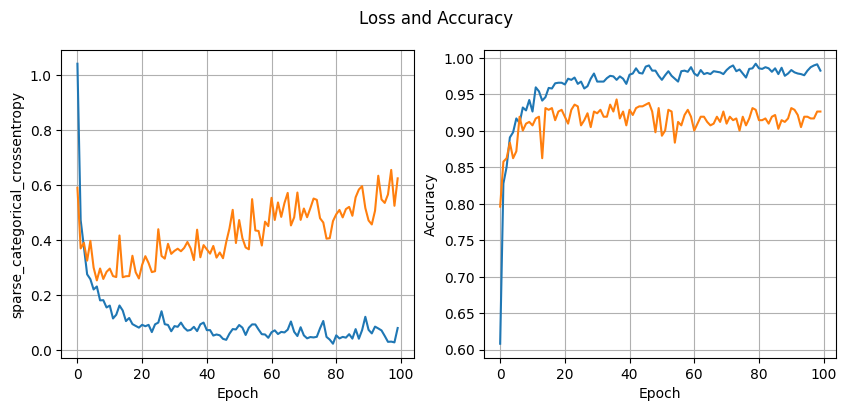

Validation accuracy: 0.9265402555465698, Validation loss: 0.6250346899032593
164 nodes, dropout 0.2, lr 0.005, batch size 64


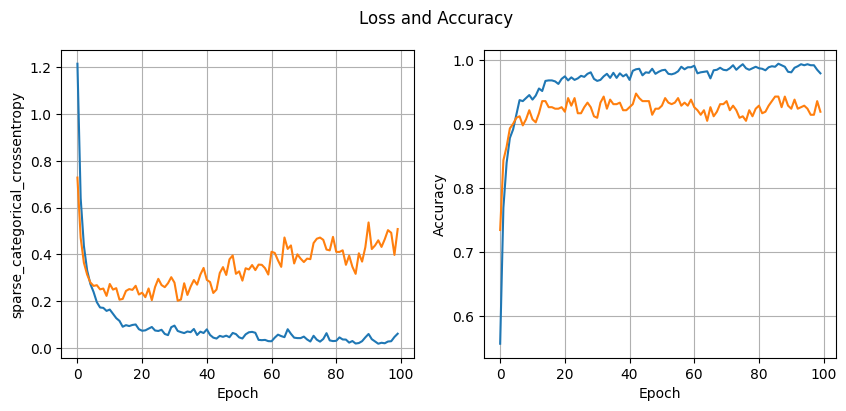

Validation accuracy: 0.9194312691688538, Validation loss: 0.5080803036689758
164 nodes, dropout 0.2, lr 0.005, batch size 128


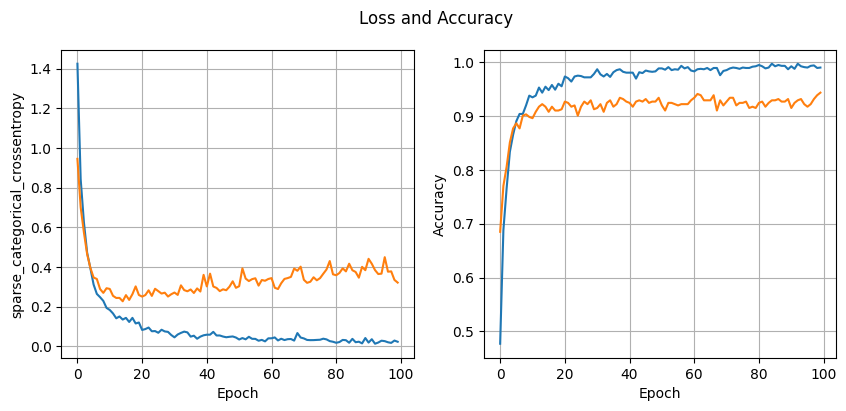

Validation accuracy: 0.9431279897689819, Validation loss: 0.3214320242404938
164 nodes, dropout 0.2, lr 0.001, batch size 32


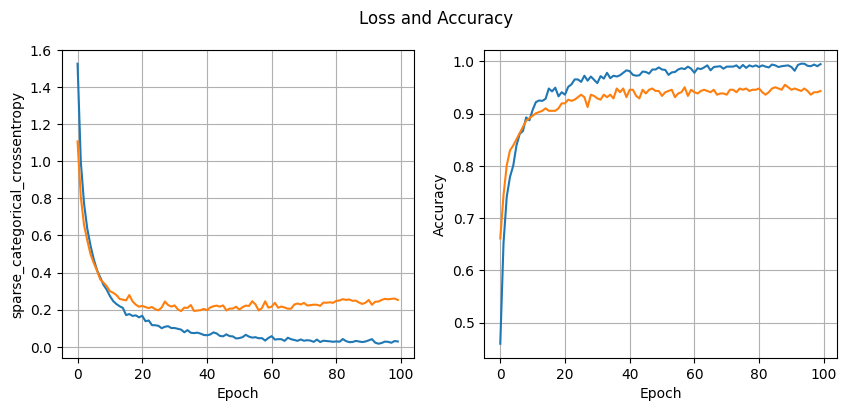

Validation accuracy: 0.9431279897689819, Validation loss: 0.25253555178642273
164 nodes, dropout 0.2, lr 0.001, batch size 64


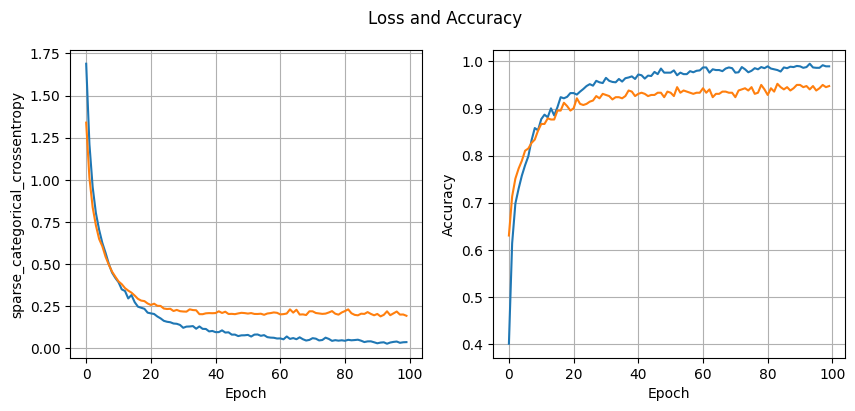

Validation accuracy: 0.9478672742843628, Validation loss: 0.1919703334569931
164 nodes, dropout 0.2, lr 0.001, batch size 128


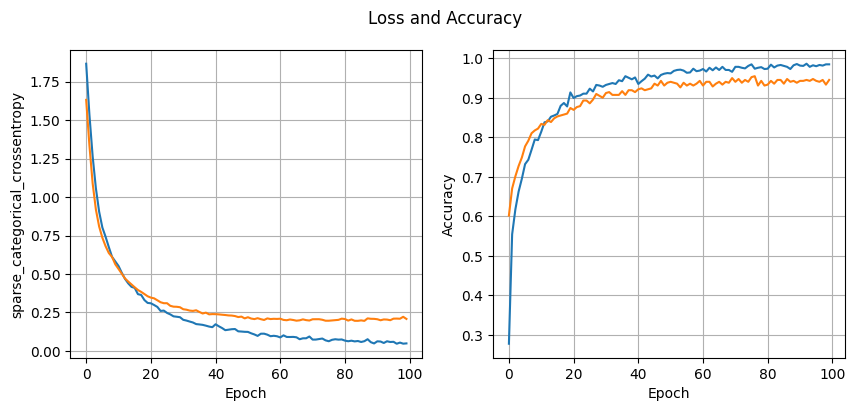

Validation accuracy: 0.9454976320266724, Validation loss: 0.2081797868013382


In [42]:
least_val_loss = float('inf')
least_loss_model = None
best_epoch = 0
epochs = 100
for num_nodes in [ 32, 64, 164]:
  for dropout_prob in [0.0, 0.1, 0.2]:
    for lr in [0.01, 0.005, 0.001]:
      for batch_size in [32, 64, 128]:
        print(f"{num_nodes} nodes, dropout {dropout_prob}, lr {lr}, batch size {batch_size}")
        model, history = train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
        plot_loss(history)
        val_loss, val_acc = model.evaluate(X_valid, y_valid, verbose=0)
        print(f"Validation accuracy: {val_acc}, Validation loss: {val_loss}")
        if val_loss < least_val_loss:
          least_val_loss = val_loss
          least_loss_model = model
          best_epoch = np.argmin(history.history['val_loss'])
          best_config = {
            'num_nodes': num_nodes,
            'dropout': dropout_prob,
            'lr': lr,
            'batch_size': batch_size,
            'best_epoch': best_epoch,
            'val_accuracy': val_acc
            }



In [43]:
y_pred = least_loss_model.predict(X_test)
print(y_pred)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[[1.0962394e-09 2.5747746e-01 7.4250633e-01 ... 1.0905857e-07
  1.1520470e-19 2.9973969e-18]
 [6.2726295e-01 3.7273708e-01 1.4605320e-11 ... 6.6631137e-37
  0.0000000e+00 0.0000000e+00]
 [5.4363220e-04 9.9932796e-01 1.2839238e-04 ... 3.2021080e-16
  2.8456760e-33 4.5041374e-30]
 ...
 [3.5760601e-03 9.9642229e-01 1.6498689e-06 ... 6.5964135e-22
  0.0000000e+00 2.8381198e-38]
 [0.0000000e+00 6.0810216e-25 3.9277925e-24 ... 1.6391311e-02
  9.8360866e-01 3.2566547e-11]
 [7.0574883e-12 1.5604299e-05 7.6809945e-04 ... 3.9675788e-04
  2.1010861e-18 1.5119657e-17]]


In [44]:
# Convert to class labels (integers 0–6):
y_pred_classes = np.argmax(y_pred, axis=1)
print(y_pred_classes)

[2 0 1 6 3 2 6 4 1 5 6 4 0 4 2 0 0 5 0 6 5 6 3 1 1 6 5 0 2 1 2 0 2 3 4 0 5
 2 5 3 4 4 5 1 5 0 2 2 6 5 4 4 6 6 5 3 6 1 0 2 5 5 5 1 6 5 4 6 6 6 1 3 4 4
 2 5 5 4 1 3 3 4 2 6 6 5 5 0 1 1 2 3 3 4 3 0 4 0 2 3 1 1 0 1 3 1 4 5 2 2 2
 4 4 6 2 6 3 1 6 4 6 0 5 6 6 3 6 4 4 5 1 1 2 4 1 6 4 4 6 6 2 4 6 0 5 4 0 0
 4 6 5 5 5 5 1 4 2 0 4 5 5 6 0 4 3 4 0 2 4 1 1 2 3 6 6 2 6 4 1 5 6 6 5 1 6
 4 5 5 0 5 4 4 3 4 1 5 5 5 3 4 4 5 6 5 4 4 3 4 0 1 3 0 2 2 4 5 3 5 4 3 4 1
 5 0 0 3 2 0 1 3 3 1 0 2 6 1 3 3 5 2 3 0 3 6 4 3 3 4 1 0 3 3 4 5 1 2 5 3 0
 0 4 4 5 4 2 2 5 1 6 0 2 3 2 4 4 3 0 5 4 4 6 0 6 1 4 1 0 5 5 4 5 6 1 4 5 2
 2 6 2 6 1 5 4 6 4 1 0 5 4 0 2 0 2 3 3 2 5 4 2 0 1 2 2 2 5 5 3 4 0 2 0 6 0
 1 4 6 6 2 1 0 0 6 3 4 4 4 2 6 4 0 4 5 5 4 0 6 6 3 5 4 0 4 3 6 1 6 6 0 2 2
 3 3 3 4 6 3 0 2 2 3 5 6 4 1 1 1 3 3 2 6 5 6 0 0 0 6 0 6 5 1 3 0 6 2 3 1 0
 4 3 4 3 2 5 3 1 5 0 2 1 3 1 5 3]


In [45]:
y_test

array([2, 0, 1, 6, 3, 2, 6, 4, 1, 5, 6, 4, 0, 4, 2, 0, 0, 5, 0, 6, 5, 6,
       3, 1, 1, 6, 5, 0, 2, 1, 2, 0, 2, 3, 4, 0, 5, 2, 5, 3, 4, 4, 5, 1,
       5, 0, 2, 2, 6, 5, 4, 4, 6, 6, 6, 3, 6, 0, 0, 2, 5, 5, 5, 1, 6, 5,
       4, 6, 6, 6, 1, 3, 4, 4, 2, 5, 5, 4, 1, 3, 3, 4, 3, 6, 6, 5, 5, 0,
       1, 1, 2, 3, 3, 4, 3, 0, 4, 0, 2, 3, 1, 1, 0, 2, 3, 1, 4, 5, 2, 3,
       2, 4, 4, 6, 2, 6, 3, 1, 6, 4, 6, 0, 5, 6, 6, 3, 6, 4, 4, 5, 1, 1,
       2, 4, 1, 6, 4, 4, 6, 6, 2, 4, 6, 0, 5, 4, 0, 0, 4, 6, 5, 5, 4, 5,
       0, 3, 2, 0, 4, 5, 5, 6, 0, 4, 3, 4, 0, 2, 4, 1, 1, 2, 3, 6, 6, 3,
       6, 4, 1, 5, 6, 6, 5, 1, 6, 4, 5, 5, 0, 5, 4, 4, 3, 4, 1, 5, 5, 5,
       3, 4, 4, 5, 6, 5, 4, 4, 3, 4, 0, 1, 3, 0, 2, 2, 4, 5, 3, 5, 4, 3,
       4, 1, 5, 0, 0, 3, 2, 0, 1, 3, 3, 1, 0, 2, 6, 1, 3, 3, 5, 2, 4, 0,
       3, 6, 4, 3, 3, 4, 0, 0, 3, 3, 4, 5, 1, 2, 5, 3, 0, 0, 4, 4, 5, 4,
       2, 2, 5, 1, 6, 0, 2, 4, 2, 4, 4, 3, 0, 5, 4, 4, 6, 0, 6, 1, 4, 1,
       0, 5, 5, 4, 5, 6, 1, 4, 5, 2, 3, 6, 2, 6, 0,

In [46]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.90      0.94        62
           1       0.84      0.98      0.91        44
           2       0.91      0.96      0.93        52
           3       0.96      0.90      0.93        61
           4       0.97      0.95      0.96        78
           5       0.95      0.98      0.97        63
           6       1.00      0.98      0.99        63

    accuracy                           0.95       423
   macro avg       0.95      0.95      0.95       423
weighted avg       0.95      0.95      0.95       423



In [47]:
print("Best hyperparameters found:")
for k, v in best_config.items():
    print(f"{k}: {v}")

#manual search: 
# 64 nodes, dropout 0.2, lr 0.005, batch size 64
# Validation accuracy: 0.950236976146698, Validation loss: 0.1457110345363617

Best hyperparameters found:
num_nodes: 32
dropout: 0.2
lr: 0.005
batch_size: 64
best_epoch: 75
val_accuracy: 0.9478672742843628


In [48]:
least_loss_model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_69 (Dense)                     │ (None, 32)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_44 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_70 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_45 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_71 (Dense)                     │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,399 (21.09 KB)

 Trainable params: 1,799 (7.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,600 (14.07 KB)

In [49]:
np.argmax([2.8360744e-22, 6.5730287e-06, 6.5177399e-01, 5.7004299e-03, 1.0686001e-09, 2.5023541e-11])

2

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)


In [51]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['Obesity'])


In [52]:
print(label_encoder.classes_)


[0 1 2 3 4 5 6]


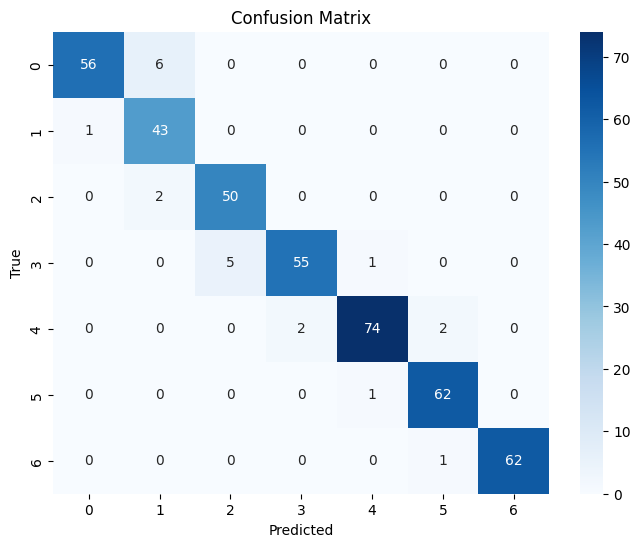

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
